<a href="https://colab.research.google.com/github/Sharvari303/Big_data_course_project_CIS545/blob/main/Copy_of_cis545_proj_rna_structure_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CIS 545 Final Project - RNA Secondary Structure Prediction**
## Spring 2024

**Group 117:** Hoang Dinh & Sharvari Kemkar

**Final version (Submitted on: Wed, May 1, 2024)**


# Part 1: Introduction

The objective of this project is to develop a machine learning model that accurately predicts number of RNA secondary structures from their nucleotide sequences. This endeavor aims to improve our understanding of the structural configurations of RNAs, which are crucial for their diverse biological functions despite not encoding proteins.

Predicting RNA secondary structures is a critical challenge in molecular biology with significant implications for understanding gene regulation, cellular processes, and disease mechanisms. Non-coding RNAs, which make up a substantial part of the human genome, are central to numerous biological functions, but their roles are often dictated by their secondary structures. An accurate predictive model for RNA secondary structures would be a valuable tool for researchers, enabling deeper insights into RNA biology and potentially facilitating the development of RNA-based therapeutic strategies. This project leverages the **comprehensive bpRNA dataset** to build a predictive model, aiming to contribute a reliable computational tool to the field of RNA research.

This notebook is divided into 6 parts:
1. Introduction
2. Data import and preprocessing
3. Exploratory Data Analysis
4. Predicting number of substructures from RNA sequence (Regression)
5. Predicting the secondary structure (dot-bracket format) from RNA sequence (Classification)
6. Conclusion



In [ ]:
#code for generating illustration of neural network architecture

from graphviz import Digraph

dot = Digraph()

dot.node('A', 'Input Layer\n(batch_size, sequence_length)')
dot.node('B', 'Embedding Layer\n(batch_size, sequence_length, embedding_dim)')
dot.node('C', 'GRU Layer\n(batch_size, sequence_length, units)')
dot.node('D', 'TimeDistributed Dense Layer\n(batch_size, sequence_length, num_classes)')
dot.node('E', 'Output (Softmax)')

dot.edges(['AB', 'BC', 'CD', 'DE'])

dot.render('model_diagram', format='png', cleanup=True)

# Part 1.5: Import and Data Loading

Unless this is the first time you run, dataset were already imported and pre-processed in **Part 2**. Run this part instead of Part 2 to import packages and load the saved cleaned dataset (csv files) from Google Drive.

In [ ]:
import pandas as pd
import os
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, LSTM, Embedding, GRU, Masking
from tensorflow.keras.layers import Bidirectional, Input, TimeDistributed
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.optimizers import Adam
!pip install keras-tuner
from kerastuner import HyperModel, RandomSearch



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.2 MB/s eta 0:00:00


<ipython-input-1-2b840b4d9379>:20: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import HyperModel, RandomSearch


In [ ]:
# Run this cell to mount your drive (you will be prompted to sign in)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
rna_df = pd.read_csv('/content/drive/MyDrive/CIS_545_fin_proj/cleaned_data/rna_df.csv')
sub_df = pd.read_csv('/content/drive/MyDrive/CIS_545_fin_proj/cleaned_data/sub_df.csv')

# Part 2: Data Import and Preprocessing

For our analysis, we utilize the **bpRNA-1m** dataset, which comprises 102,318 RNA secondary structures from seven different sources. This dataset provides comprehensive files for each RNA, including BPSEQ files for base pairing information, FASTA files for primary sequences, dot bracket files for secondary structure notation, structure type files for categorizing structural elements, and visual PDFs for each structure.

In this section, we extract the relevant sequence and secondary structure information from these files and store it in Pandas DataFrames for downstream applications.

## 2.1 Import bp100-RNA Data

First, let look at the structure of each ST file, part-by-part:

1.   Name of the RNA sequence (internal to bpRNA dataset).
2.   Length of RNA sequence.
3.   Page Number: the number of representation plane for secondary structure of the RNA sequence.
4.   RNA sequence (A, U, G, C).
5.   Dot-bracket structure - a representation for secondary structure.
6.   Classification of each nucleotide, denoting which substructure each nucleotide belongs to. **S** = stem, **H** = hairpin loop, **M** = multi-loop, **I** = internal loop, **B** = bulge, **X** = external loop, and **E** = end.
7.   "NK" sequence denotes whether each nucleotide is unpaired or nested (**N**) or forms pseudoknot (**K**).
8.   Sequences starting with (S, H, M, I, B, X, E) describes the base pairing of the substructure. I and M have discontinuous parts forming a loop, and therefore they are divided into sections such as I1.1, I1.2.
9.   "PK" sequence describes pseudoknots substructure.
10.  "NCBP" sequence describes non-canonical base-pairing segments.
11.  "segment" describes divded segments of the RNA sequence.

In [ ]:
sample_data = open('/content/drive/My Drive/CIS_545_fin_proj/sample_data/bpRNA_CRW_1.st', 'r')
print(sample_data.read())

#Name: bpRNA_CRW_1
#Length:  1434 
#PageNumber: 2
#Warning: Structure contains linked PK-segments of same sizes 1 and 1. Using PK brackets for the more 5' segment
ACACAUGCAAGCGAACGUGAUCUCCAGCUUGCUGGGGGAUUAGUGGCGAACGGGUGAGUAACACGUGAGUAACCUGCCCUUGACUCUGGGAUAAGCCUGGGAAACUGGGUCUAAUACUGGAUACGACCUUCCCACGCAUGUGUGUUGGUGGAAAGCUUUUGUGGUUUUGGAUGGACUCGCGGCCUAUCAGCUUGUUGGUGGGGUAAUGGCCUACCAAGGCGACGACGGGUAGCCGGCCUGAGAGGGUGGACGGCCACACUGGGACUGAGACACGGCCCAGACUCCUACGGGAGGCAGCAGUGGGGAAUAUUGCACAAUGGGCGCAAGCUGAUGCAGCGACGCCGCGUGAGGGAUGAAGGCCUUCGGGUUGUAAACCUCUUUCAGUAGGGAAGAAGCGAAAGUGACGGUACCUGCAGAAGAAGCGCCGGCUAACUACGUGCCAGCAGCCGCGGUAAUACGUAGGGCGCAAGCGUUAUCCGGAAUUAUUGGGCGUAAAGAGCUCGUAGGCGGUUUGUCGCGUCUGCCGUGAAAGUCCGGGGCUUAACUCCGGAUCUGCGGUGGGUACGGGCAGACUUGAGUGAUGUAGGGGAGACUGGAAUUCCUGGUGUAGCGGUGAAAUGCGCAGAUAUCAGGAGGAACACCGAUGGCGAAGGCAGGUCUCUGGGCAUUAACUGACGCUGAGGAGCGAAAGCAUGGGGAGCGAACAGGAUUAGAUACCCUGGUAGUCCAUGCCGUAAACGUUGGGCACUAGGUGUGGGGGACAUUCCACGUUUUCCGCGCCGUAGCUAACGCAUUAAGUGCCCCGCCUGGGGAGUACGGCCGCAAGGCUAAAACUCA

### 2.2.1 RNA Dataset
Based on the above structure of the ST files, let's create RNA dataset rna_df with the following schema:
> `rna_name` `length` `sequence` `dot_bracket_structure` `S` `H` `M` `I` `B` `X` `E`

where S = stem, H = hairpin loop, M = multi-loop, I = internal loop, B = bulge, X = external loop, E = end, representing the number of each substructure in the sequence.

We need to loop through each of the ST file, capture relevant information, and create new features by counting the number of each substructure in each RNA sequence.

All of the ST files are compressed into a zip file to make it convenient. We need to write two separate functions: one to access the zip file and one to extract information from individual ST file.

In [ ]:
# Read ST files and extract required information.
def parse_st_file(file_contents):
    lines = file_contents.decode('utf-8').splitlines()

    data = {
        'rna_name': lines[0].strip().split(':')[-1].strip(), # Line 0, strip all white spaces, split at :, take the last element, then strip again
        'length': lines[1].strip().split(':')[-1].strip(),
        'sequence': lines[4].strip() if lines[3].startswith('#Warning') else lines[3].strip(),
        'dot_bracket_structure': lines[5].strip() if lines[3].startswith('#Warning') else lines[4].strip(),
        'S': 0,  # stem
        'H': 0,  # hairpin loop
        'M': 0,  # multi-loop
        'I': 0,  # internal loop
        'B': 0,  # bulge
        'X': 0,  # external loop
        'E': 0   # end
    }

    # Loop through lines starting from line 9 to extract types and counts
    type_lines = lines[8:] if lines[3].startswith('#Warning') else lines[7:]
    for line in type_lines:
        parts = line.split()
        if parts:
            element_type = parts[0][0]  # First character of the first word, e.g., 'H', 'M'
            if element_type in ['S', 'H', 'M', 'I', 'B', 'X', 'E']:
                number_part = re.search(r'\d+', parts[0])  # Use regex to find the first sequence of digits
                if number_part:
                    number = number_part.group(0) # Extract the matched number
                    data[element_type] = max(data[element_type], int(number))  # Track the maximum number

    return data

# Read and access ST files within the zip file.
def process_zip_file(zip_path):
    data_list = []
    folder_prefix = 'stFiles/'  # Path within the zip to the folder containing .st files
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Include all files in the specified folder
        st_files = [f for f in z.namelist() if f.startswith(folder_prefix)]
        for filename in st_files:
            with z.open(filename) as file:
                file_data = parse_st_file(file.read())
                data_list.append(file_data)

    return pd.DataFrame(data_list)

In [ ]:
# Create rna_df
dataset_path = '/content/drive/My Drive/CIS_545_fin_proj/stFiles.zip'
rna_df = process_zip_file(dataset_path)

Let's examine the dataframe and look at the few first columns. The size and dimensions of `rna_df` agree with the specifications from bpRNA dataset (i.e., about 100,000 data points).

In [ ]:
rna_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102318 entries, 0 to 102317
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   rna_name               102318 non-null  object
 1   length                 102318 non-null  object
 2   sequence               102318 non-null  object
 3   dot_bracket_structure  102318 non-null  object
 4   S                      102318 non-null  int64 
 5   H                      102318 non-null  int64 
 6   M                      102318 non-null  int64 
 7   I                      102318 non-null  int64 
 8   B                      102318 non-null  int64 
 9   X                      102318 non-null  int64 
 10  E                      102318 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 8.6+ MB


Let's look at the first few entries of `rna_df`.

rna_df has the following columns: name, length, sequence, dot-bracket structure, number of the 7 secondary sub structures: S, H, M, I, B, X and E.

In [ ]:
rna_df.head()

,rna_name,length,sequence,dot_bracket_structure,S,H,M,I,B,X,E
0,bpRNA_CRW_1,1434,ACACAUGCAAGCGAACGUGAUCUCCAGCUUGCUGGGGGAUUAGUGG...,.(((.(((..((..((((.(((((.((....))))))))..))))....,106,30,15,27,34,8,2
1,bpRNA_CRW_10,1476,UUUGAUCCUGGCUCAGGACGAACGCUGGCGGCGUGCUUAACACAUG...,[[...(((.]]....((((.((((((.(((((((((....(((.((...,108,30,19,29,31,0,2
2,bpRNA_CRW_100,564,GAGCGGCGAACGGGUGAGUAACACGUGAGUAACCUGCCCCAGGCUU...,.............(((......((((((((..((...(((((((.(...,33,12,2,10,9,7,2
3,bpRNA_CRW_1000,1478,ACGAACGCUGGCGGCGUGCUUAACACAUGCAAGUCGAACGAUGAAC...,((.((((((.(((((((((....(((.(((..(((..(((((.(((...,105,31,17,28,29,5,0
4,bpRNA_CRW_10000,861,AAUACGUAGGUGGCAAGCGUUAUCCGGAAUUAUUGGGCGUAAAGCG...,...................................((([[.....(...,57,17,13,13,15,0,1


### 2.2.2 Substructure Dataset
From the same source, let's create substructure dataset sub_df with the following schema:
> `substructure_type` `sequence` `rna_name`

where `substructure_type` could be S, H, M, I, B, X, E; `sequence` = sequence of substructure; `rna_name` = name of corresponding RNA (i.e., bpRNA_CRW_1).

Similarly, we need to write two functions to access the zip file and analyze the individual ST files.

In [ ]:
def parse_st_file_sub(file_content):
    """
    Parses the content of an .st file, extracting the substructure type and concatenated sequences in quotes.

    :param file_content: Byte content of a single .st file.
    :return: List of dictionaries with keys 'substructure', 'sequence', and 'rna'.
    """
    # Decode file content if necessary
    content = file_content.decode('utf-8') if isinstance(file_content, bytes) else file_content

    # Split the content into lines
    lines = content.splitlines()

    # Extract the RNA name using a regular expression
    rna_name = lines[0].strip().split(':')[-1].strip() # Line 0, strip all white spaces, split at :, take the last element, then strip again

    # Determine the start index depending on the presence of a warning line
    start_index = 8 if any(line.startswith('#Warning') for line in lines[:10]) else 7

    # Initialize data list for entries
    entries = []

    # Initialize dictionary to track substructure sequences across multiple lines
    ongoing_substructures = {}

    # Compile a pattern to find the substructure type and sequences
    pattern = re.compile(r'^([SHMIBXE]\d*)|"(?P<sequence>\w+)"')

    # Loop through the lines starting from the determined index
    for line in lines[start_index:]:
        substructure = None
        sequences = []
        for match in re.finditer(pattern, line):
            if match.group(1):
                substructure = match.group(1)  # Capture the substructure type
            elif match.lastgroup == 'sequence':
                if substructure.startswith('I') or substructure.startswith('M'): # Handle I and M cases differently since they span across multiple line for each substructure
                    if substructure in ongoing_substructures:
                        ongoing_substructures[substructure]['sequences'].append(match.group('sequence'))
                    else:
                        ongoing_substructures[substructure] = {'sequences': [match.group('sequence')], 'type': substructure[0]}
                else: # Handle the rest of the case normally
                    sequences.append(match.group('sequence'))  # Capture each sequence in quotes

        if substructure and sequences:
            # Concatenate all captured sequences
            concatenated_sequence = ''.join(sequences)
            entries.append({
                'substructure': substructure[0],
                'sequence': concatenated_sequence,
                'rna_name': rna_name
            })

    for key, value in ongoing_substructures.items():
        concatenated_sequence = ''.join(value['sequences'])
        entries.append({
            'substructure': value['type'],
            'sequence': concatenated_sequence,
            'rna_name': rna_name
        })

    return entries

# Read and access ST files within the zip file.
def process_zip_file_sub(zip_path):
    data_list = []
    folder_prefix = 'stFiles/'  # Path within the zip to the folder containing .st files
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Include all files in the specified folder
        st_files = [f for f in z.namelist() if f.startswith(folder_prefix)]
        for filename in st_files:
            with z.open(filename) as file:
                file_data = parse_st_file_sub(file.read())
                # Extend the main list with the list of dictionaries from each file
                data_list.extend(file_data)

    # Create a DataFrame from the flattened list of dictionaries
    return pd.DataFrame(data_list)

In [ ]:
# Access the zip files
dataset_path = '/content/drive/My Drive/CIS_545_fin_proj/stFiles.zip'
sub_df = process_zip_file_sub(dataset_path)

Since each RNA sequence has many substructures, the number of entries in this dataset is expected to be much larger than `rna_df`. Indeed, `sub_df` has about 4.3 million data points.

In [ ]:
sub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384939 entries, 0 to 4384938
Data columns (total 3 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   substructure  object
 1   sequence      object
 2   rna_name      object
dtypes: object(3)
memory usage: 100.4+ MB


In [ ]:
sub_df.head()

,substructure,sequence,rna_name
0,S,CACGUG,bpRNA_CRW_1
1,S,UGCGCA,bpRNA_CRW_1
2,S,GC,bpRNA_CRW_1
3,S,CG,bpRNA_CRW_1
4,S,ACGAGU,bpRNA_CRW_1


## 2.2 Data Cleanup

### 2.2.1 Cleaning `rna_df`

All elements in the `length` column are supposed to be integers. By examination, we know that some elements have dangling comma, i.e., `,32,`. Let's fix this.

In [ ]:
# Remove all non-digit character
rna_df['length'] = rna_df['length'].apply(lambda x: re.sub(r'[^\d]', '', x))

In [ ]:
# Cast length column type to int
rna_df['length'] = rna_df['length'].astype(int)

# Cast name, sequence, and dot_bracket_structure to string type
rna_df['rna_name'] = rna_df['rna_name'].astype('string')
rna_df['sequence'] = rna_df['sequence'].astype('string')
rna_df['dot_bracket_structure'] = rna_df['dot_bracket_structure'].astype('string')

In [ ]:
# Confirm the schema
rna_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102318 entries, 0 to 102317
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   rna_name               102318 non-null  string
 1   length                 102318 non-null  int64 
 2   sequence               102318 non-null  string
 3   dot_bracket_structure  102318 non-null  string
 4   S                      102318 non-null  int64 
 5   H                      102318 non-null  int64 
 6   M                      102318 non-null  int64 
 7   I                      102318 non-null  int64 
 8   B                      102318 non-null  int64 
 9   X                      102318 non-null  int64 
 10  E                      102318 non-null  int64 
dtypes: int64(8), string(3)
memory usage: 8.6 MB


Some non-canonical nucleotides are present. We are only interested in conventional nucleotide (i.e., A, U, G, C). Let's remove all entries with non-canonical nucleotides.

In [ ]:
# This function  check if the sequence contains non-canonical nucleotides.
def check_canonical_nt(seq):
    for nt in seq:
        if nt not in ['A', 'U', 'G', 'C']:
            return False
    return True

# Remove sequence with non-canonical nucleotides
rna_df = rna_df[rna_df['sequence'].apply(check_canonical_nt)]

In [ ]:
rna_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96720 entries, 0 to 102316
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   rna_name               96720 non-null  string
 1   length                 96720 non-null  int64 
 2   sequence               96720 non-null  string
 3   dot_bracket_structure  96720 non-null  string
 4   S                      96720 non-null  int64 
 5   H                      96720 non-null  int64 
 6   M                      96720 non-null  int64 
 7   I                      96720 non-null  int64 
 8   B                      96720 non-null  int64 
 9   X                      96720 non-null  int64 
 10  E                      96720 non-null  int64 
dtypes: int64(8), string(3)
memory usage: 8.9 MB


Cleaned rna_df now has 96,720 entries, meaning that 5598 entries containing non-canonical nt have been removed.

### 2.2.2 Cleaning `sub_df`

Entries containing non-canonical nucleotide also need to be removed in this DataFrame.

In [ ]:
sub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384939 entries, 0 to 4384938
Data columns (total 3 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   substructure  object
 1   sequence      object
 2   rna_name      object
dtypes: object(3)
memory usage: 100.4+ MB


In [ ]:
# Remove entries that contain non-canonical nucleotide in sub_df
unique_rna_df = rna_df['rna_name'].copy()
sub_df = sub_df.merge(unique_rna_df, left_on='rna_name', right_on='rna_name')

In [ ]:
sub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3581555 entries, 0 to 3581554
Data columns (total 3 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   substructure  object
 1   sequence      object
 2   rna_name      object
dtypes: object(3)
memory usage: 82.0+ MB


After removing sequences containing non-canonical nucleotides, we are left with about 3.5 million data points in `sub_df`, removing almost 1 million data points.

## 2.3 Saving Cleaned Dataset to Drive

To save time for future runs, cleaned datasets are saved to Drive. Next time, there's no need to run Part 2 again.

In [ ]:
rna_df.to_csv('rna_df.csv', index=False)
sub_df.to_csv('sub_df.csv', index=False)


!cp rna_df.csv /content/drive/MyDrive/CIS_545_fin_proj/cleaned_data
!cp sub_df.csv /content/drive/MyDrive/CIS_545_fin_proj/cleaned_data

# Part 3: Exploratory Data Analysis

This section investigates relationships between the lengths and compositions of RNA sequences and their substructures using the bpRNA-1m dataset. Our objective is to identify trends that assist in the predictive modeling of RNA structures.

**Key Findings**
1. RNA sequences predominantly range under 200 nt, with notable exceptions up to 4381 nt, suggesting length capping may be beneficial for modeling.
2. Analysis reveals typical substructure lengths between 5 and 10 nucleotides, with exceptions in bulges and hairpin loops, indicating complex formation dynamics.
3. Significant correlations observed include a strong positive between RNA length and substructure count (0.99), and a very high negative between ends and stems (-0.93).
4. Insights into nucleotide distributions across different substructures suggest structural preferences.

## 3.1 Length Distribution of RNA


The first task is to look at the length distribution of RNA in the bpRNA dataset.

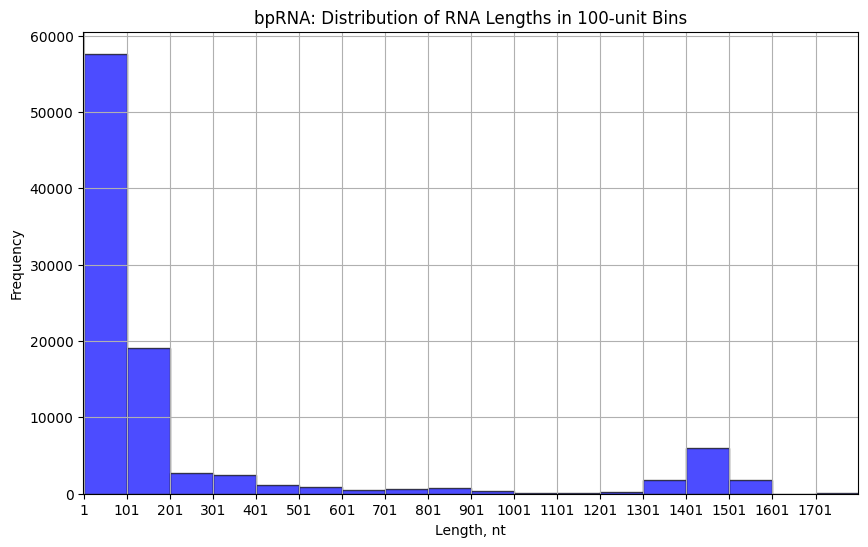

In [ ]:
plt.figure(figsize=(10, 6))  # Set the size of the figure

# Calculate bins from the minimum length to the maximum length with a 100 unit increment
bins = np.arange(start=rna_df['length'].min(), stop=rna_df['length'].max() + 100, step=100)

# Create histogram with specified bins
plt.hist(rna_df['length'], bins=bins, color='blue', edgecolor='black', alpha=0.7)

plt.title('bpRNA: Distribution of RNA Lengths in 100-unit Bins')  # Title of the histogram
plt.xlabel('Length, nt')  # Label for the x-axis
plt.ylabel('Frequency')  # Label for the y-axis
plt.grid(True)  # Enable grid for better readability

# Adding x-ticks to clearly mark the bins
plt.xticks(bins)

plt.xlim((0, 1800))

plt.show()  # Display the plot

In [ ]:
# Calculate maximum sequence length
longest_sequence = max(rna_df['sequence'].str.len())
print("Maximum length of RNA sequence in the input data:", longest_sequence)

Maximum length of RNA sequence in the input data: 4381


Our exploratory data analysis revealed that the majority of the RNA sequences in our dataset are less than 200 nucleotides (nt) in length. However, there is a significant subset of sequences ranging between 1300-1600 nt, with the maximum length goes up to 4381. This distribution has important implications for the preprocessing steps in our machine learning pipeline, particularly when dealing with sequence padding.

**Implications of these observations on Model Building**

Given the skewed distribution of sequence lengths, it is advisable to cap the length of RNA sequences at 500 nt for the following reasons:

1. Reduced Padding: Capping at 500 nt minimizes the amount of padding required for shorter sequences, which constitute the majority of our dataset. This approach prevents the model from learning from excessive zero-padding, which can dilute the signal in the data.
2. Computational Efficiency: Limiting sequence length to 500 nt enhances computational efficiency by reducing the memory and processing power required, thus speeding up the training phase.
3. Balancing Sequence Representation: By capping the sequence length, we ensure that longer sequences do not disproportionately influence the model's learning, providing a more balanced representation of the typical structures within our data.

## 3.2 Length Distribution of Substructure

First, let's add a `length` column that measures the length of the substructure.

In [ ]:
# Calculate length of sequence
sub_df['length'] = sub_df['sequence'].apply(lambda x: len(x))

In [ ]:
sub_df.head()

,substructure,sequence,rna_name,length
0,S,CACGUG,bpRNA_CRW_1,6
1,S,UGCGCA,bpRNA_CRW_1,6
2,S,GC,bpRNA_CRW_1,2
3,S,CG,bpRNA_CRW_1,2
4,S,ACGAGU,bpRNA_CRW_1,6


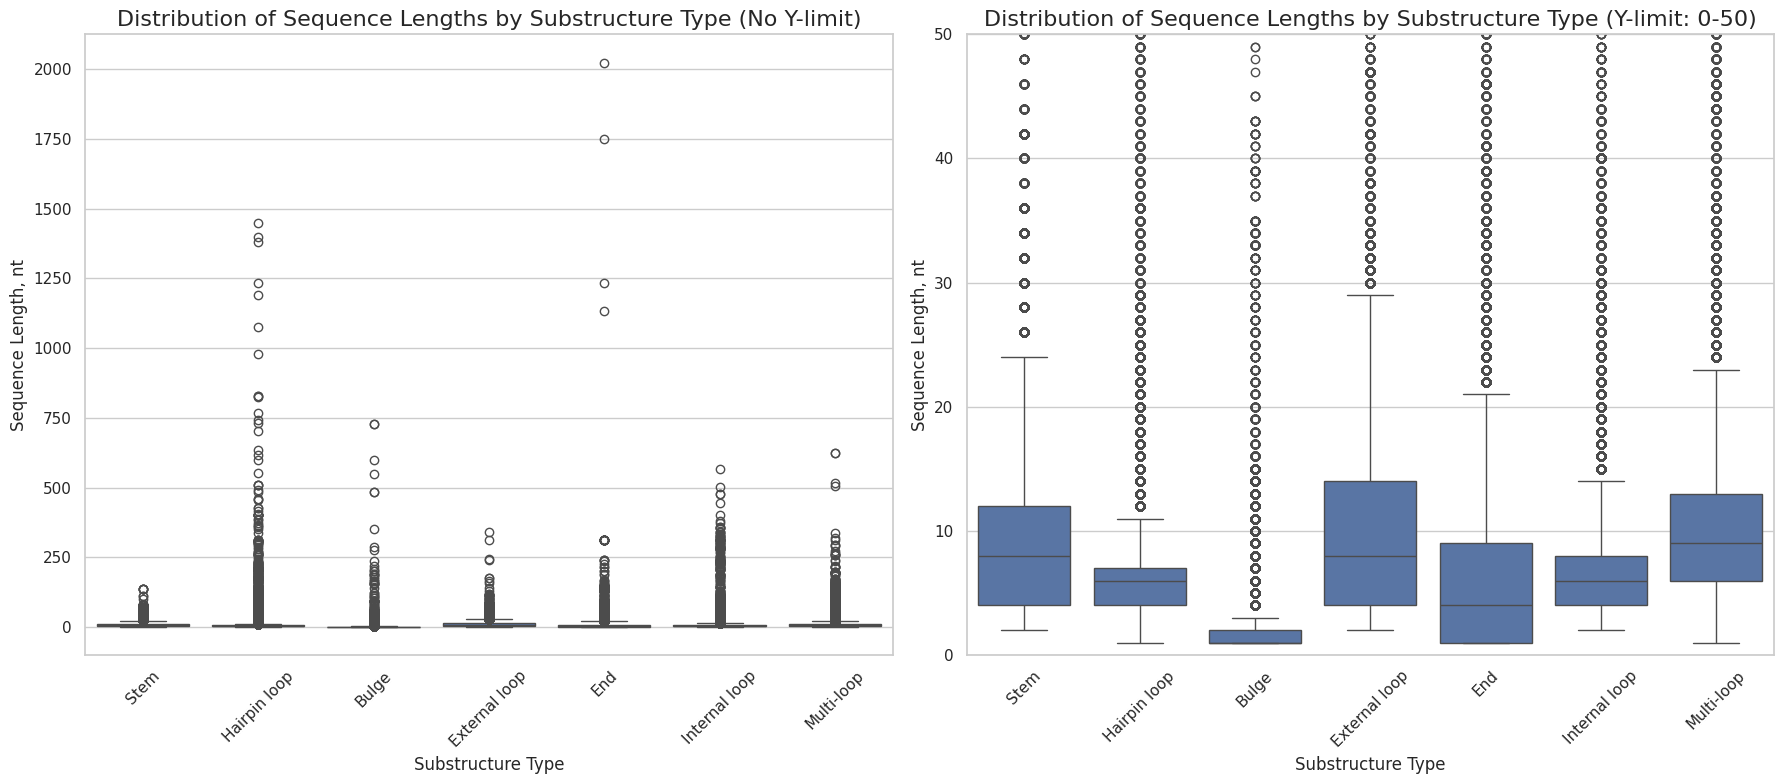

In [ ]:
# Mapping dictionary
substructure_names = {
    'S': 'Stem',
    'H': 'Hairpin loop',
    'M': 'Multi-loop',
    'I': 'Internal loop',
    'B': 'Bulge',
    'X': 'External loop',
    'E': 'End'
}

# Set up the matplotlib figure with two side-by-side subplots
plt.figure(figsize=(18, 8))  # Adjust overall figure size to better fit side-by-side plots
sns.set(style="whitegrid")

# First subplot without ylim
plt.subplot(1, 2, 1)  # One row, two columns, first plot
box1 = sns.boxplot(x=sub_df['substructure'].map(substructure_names), y='length', data=sub_df)
plt.title('Distribution of Sequence Lengths by Substructure Type (No Y-limit)', fontsize=16)
plt.xlabel('Substructure Type', fontsize=12)
plt.ylabel('Sequence Length, nt', fontsize=12)
plt.xticks(rotation=45)

# Second subplot with ylim
plt.subplot(1, 2, 2)  # One row, two columns, second plot
box2 = sns.boxplot(x=sub_df['substructure'].map(substructure_names), y='length', data=sub_df)
plt.title('Distribution of Sequence Lengths by Substructure Type (Y-limit: 0-50)', fontsize=16)
plt.xlabel('Substructure Type', fontsize=12)
plt.ylabel('Sequence Length, nt', fontsize=12)
plt.ylim([0, 50])
plt.xticks(rotation=45)

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

Our analysis of the lengths of various RNA substructures reveals interesting insights on the size of RNA secondary structures.

1. **Median Lengths**: The median lengths of most RNA substructures fall between 5 and 10 nucleotides. This general trend is consistent across various substructures, with one notable exception: bulge.
2. **Bulges**: The median length for bulges is notably shorter compared to other substructures. This observation is consistent with the definition of bulges as short, unpaired segments within the more rigid, paired sections of RNA stems, naturally resulting in shorter lengths.
3. **Hairpin Loops**: Hairpin loops present a unique case with many outliers, where lengths can extend up to nearly 1500 nt. This deviation is significant as it represents a considerable variance from the typical substructure sizes.
4. **Dangling Ends**: RNA sequences may also exhibit dangling ends, which can extend over 2000 nt without forming any secondary structures.

The presence of many outliers in substructure lengths can be partly explained by the length distribution of the overall RNA sequences, as detailed in Figure 3.1. It appears that longer RNA sequences are more likely to contain extended substructures, suggesting a correlation between the total RNA length and the maximum substructure size.

## 3.3 Heatmap

We utilize a correlation heatmap to visualize and analyze the linear relationships between several key features of RNA sequences. These features include:
1.   Length of RNA.
2.   % nt (A, U, G, C).
3.   Total number of substructure.
4.   % each substructure within an RNA sequence.
5.   Maximum length of each substructure.

To get this heatmap, the goal is to create a dataframe `heatmap_df` that has the following schema:
> `length`	`%A`	`%U`	`%G`	`%C`	`total_no_substructure`	`%S`	`%H`	`%M`	`%I`	`%B`	`%X`	`%E`	`B_max`	`E_max`	`H_max`	`I_max`	`M_max`	`S_max`	`X_max`

where the columns correspond to the list of heatmap variables above, respectively.

To do this, we first need to create a dataframe `sub_max_length_df` that has the following schema:
> `rna_name` `B_max` `E_max` `H_max` `I_max` `M_max` `S_max` `X_max`

where each column except the first column corresponds to the maximum length of a substructure type in a specific RNA sequence.

For the remaining columns in `heatmap_df`, we can derive them from `rna_df` with appropriate functions to obtain total number of substructures and percentages before the final table join.

In [ ]:
# Group by rna_name and substructure of sub_df to get the max length of each substructure
sub_max_length_df = sub_df.groupby(['rna_name', 'substructure'])['length'].max()

# Pivot the table to put the maximum lengths as columns
sub_max_length_df = sub_max_length_df.reset_index().pivot_table(index='rna_name', columns='substructure', values='length', fill_value=0).reset_index()

# Rename the columns accordingly
col_name = {
    'B': 'B_max',
    'E': 'E_max',
    'H': 'H_max',
    'I': 'I_max',
    'M': 'M_max',
    'S': 'S_max',
    'X': 'X_max'
}

sub_max_length_df = sub_max_length_df.rename(columns=col_name)

In [ ]:
sub_max_length_df.head(5)

substructure,rna_name,B_max,E_max,H_max,I_max,M_max,S_max,X_max
0,bpRNA_CRW_1,6,4,10,12,15,24,21
1,bpRNA_CRW_10,6,6,10,12,21,24,0
2,bpRNA_CRW_100,6,30,10,12,10,18,42
3,bpRNA_CRW_1000,6,0,12,12,15,24,12
4,bpRNA_CRW_10000,3,35,9,10,22,24,0


Now that `sub_max_length_df` is ready, we use `rna_df` to derive the remaining columns and merge the resulting df with `sub_max_length_df` on `rna_name` to get the desired `heatmap_df`.

In [ ]:
def calculate_nucleotide_percentage(sequence):
    # Remove any non-nucleotide characters (like dots or ellipses) for accurate calculation
    cleaned_sequence = sequence.replace('.', '')
    total = len(cleaned_sequence)

    # Calculate percentage for each nucleotide
    percent_a = (cleaned_sequence.count('A') / total) * 100 if total > 0 else 0
    percent_u = (cleaned_sequence.count('U') / total) * 100 if total > 0 else 0
    percent_g = (cleaned_sequence.count('G') / total) * 100 if total > 0 else 0
    percent_c = (cleaned_sequence.count('C') / total) * 100 if total > 0 else 0

    return percent_a, percent_u, percent_g, percent_c

In [ ]:
# Create a copy of rna_df
rna_heatmap_df = rna_df.copy()

In [ ]:
# Apply the function to the sequence column and create new columns for each nucleotide percentage
rna_heatmap_df['%A'], rna_heatmap_df['%U'], rna_heatmap_df['%G'], rna_heatmap_df['%C'] = zip(*rna_heatmap_df['sequence'].apply(calculate_nucleotide_percentage))

In [ ]:
# Add a new column of total number of substructures
rna_heatmap_df['total_no_substructure'] = rna_heatmap_df['S'] + rna_heatmap_df['H'] + rna_heatmap_df['M'] + rna_heatmap_df['I'] + rna_heatmap_df['B'] + rna_heatmap_df['X'] + rna_heatmap_df['E']

In [ ]:
# Add a new column of % of substructures
for col in ['S', 'H', 'M', 'I', 'B', 'X', 'E']:
    new_col = '%' + col
    rna_heatmap_df[new_col] = rna_heatmap_df[col]*100 / rna_heatmap_df['total_no_substructure']

In [ ]:
# Merge rna_heatmap_df with sub_max_length_df
rna_heatmap_df = rna_heatmap_df.merge(sub_max_length_df, left_on='rna_name', right_on='rna_name', how='inner')

In [ ]:
# Drop unrelated columns for heatmap
rna_heatmap_df = rna_heatmap_df.drop(columns=['rna_name', 'sequence', 'dot_bracket_structure', 'S', 'H', 'M', 'I', 'B', 'X', 'E'])

rna_heatmap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94293 entries, 0 to 94292
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   length                 94293 non-null  int64  
 1   %A                     94293 non-null  float64
 2   %U                     94293 non-null  float64
 3   %G                     94293 non-null  float64
 4   %C                     94293 non-null  float64
 5   total_no_substructure  94293 non-null  int64  
 6   %S                     94293 non-null  float64
 7   %H                     94293 non-null  float64
 8   %M                     94293 non-null  float64
 9   %I                     94293 non-null  float64
 10  %B                     94293 non-null  float64
 11  %X                     94293 non-null  float64
 12  %E                     94293 non-null  float64
 13  B_max                  94293 non-null  int64  
 14  E_max                  94293 non-null  int64  
 15  H_

In [ ]:
rna_heatmap_df.head()

,length,%A,%U,%G,%C,total_no_substructure,%S,%H,%M,%I,%B,%X,%E,B_max,E_max,H_max,I_max,M_max,S_max,X_max
0,1434,23.012552,20.223152,33.333333,23.430962,222,47.747748,13.513514,6.756757,12.162162,15.315315,3.603604,0.900901,6,4,10,12,15,24,21
1,1476,22.289973,19.783198,33.943089,23.983740,219,49.315068,13.698630,8.675799,13.242009,14.155251,0.000000,0.913242,6,6,10,12,21,24,0
2,564,21.453901,18.971631,35.992908,23.581560,75,44.000000,16.000000,2.666667,13.333333,12.000000,9.333333,2.666667,6,30,10,12,10,18,42
3,1478,22.598106,17.997294,33.897158,25.507442,215,48.837209,14.418605,7.906977,13.023256,13.488372,2.325581,0.000000,6,0,12,12,15,24,12
4,861,26.364692,22.996516,29.384437,21.254355,116,49.137931,14.655172,11.206897,11.206897,12.931034,0.000000,0.862069,3,35,9,10,22,24,0


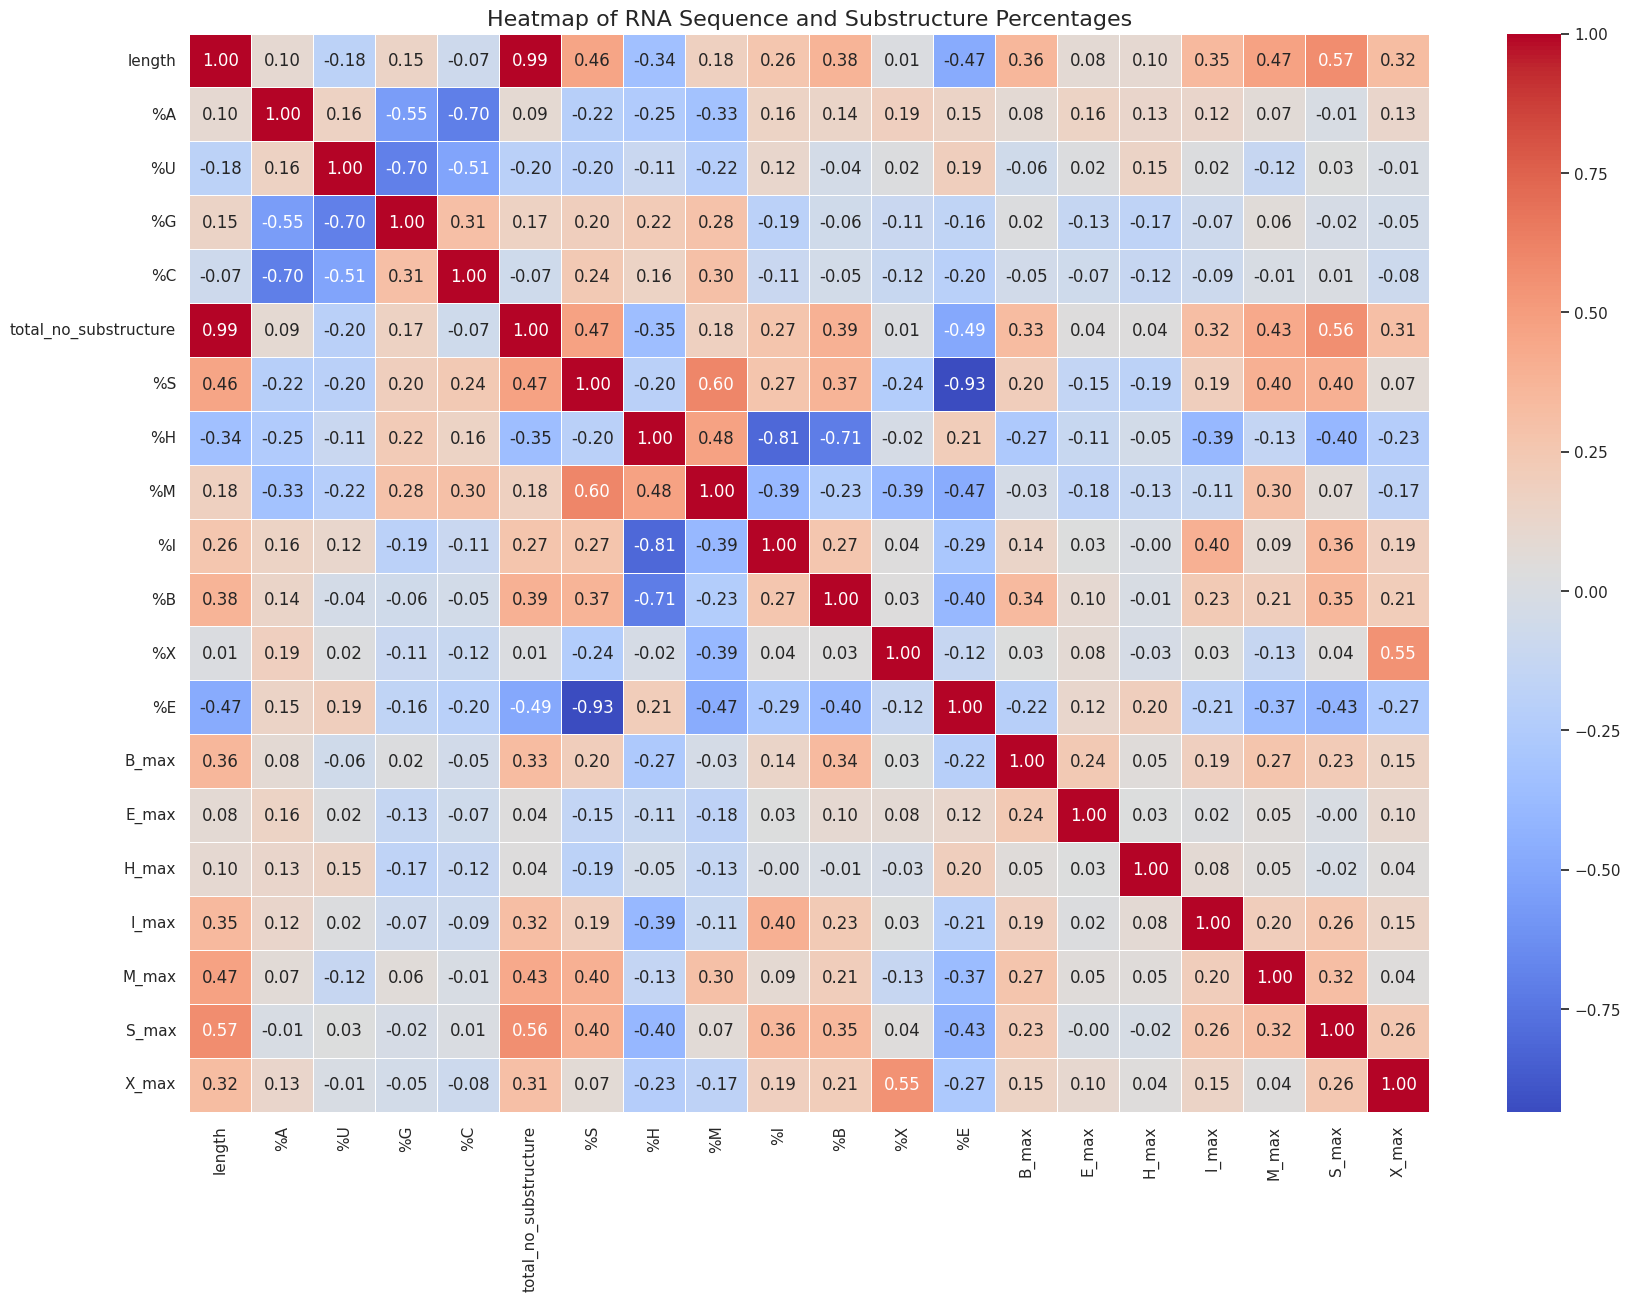

In [ ]:
# Create a smaller DataFrame with the columns of interest
heatmap_df = rna_heatmap_df.copy()

# Setting the figure size
plt.figure(figsize=(20, 14))

# Create the heatmap
sns.heatmap(heatmap_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Adding titles and labels
plt.title('Heatmap of RNA Sequence and Substructure Percentages', fontsize=16)
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.yticks(rotation=0)   # Keep y labels horizontal for clarity

# Show the plot
plt.show()

1. **RNA length** vs. **total number of substructure**:
Our analysis reveals a positive linear correlation (0.99) between the length of RNA sequences and the total number of substructures they contain. This relationship is expected as longer RNA sequences provide more nucleotides, thus offering greater opportunities for the formation of secondary structures. This observation also suggests that longer RNA sequences do not guarantee longer secondary structures.

    Figure 3.2 highlights outliers in substructure lengths, which are predominantly found in longer RNA sequences. This observation might initially seem contradictory; however, it underscores an important aspect of RNA structure formation: although a longer RNA sequence is a necessary condition for the formation of a long secondary structure, it is not a sufficient condition. Many long RNA sequences do not automatically form long secondary structures. This distinction is vital for understanding RNA folding dynamics and informs our approach to modeling RNA structure-function relationships. Longer sequences may have more structural complexity, but the actual length and formation of specific substructures depend on various factors including sequence composition and interaction dynamics among nucleotides.

2. **RNA length** vs. **maximum length of substructure**: The heatmap reveals a moderate correlation (coefficient of 0.57) between RNA sequence length and stem length, suggesting that longer sequences tend to support longer stems, albeit not in a strictly linear fashion. In contrast, hairpin loop lengths show almost no correlation with sequence length. This agrees with the conclusion from `1` that longer RNA sequences do not guarantee longer secondary structures.

These findings confirm that while the total length of RNA provides the substrate for secondary structures, the specific lengths of substructures like hairpin loops are more influenced by sequence-specific interactions than by the sequence length itself. This highlights the complex nature of RNA folding and emphasizes the need for predictive models for RNA secondary structure.

3. **Percentage of end** vs. **percentage of stem**: We observed a very high negative correlation (coefficient of -0.93) between the number of ends and number of stems in an RNA sequence. This significant inverse relationship can be attributed to the contrasting natures of these structures; stems are formed by double-stranded regions of RNA, while ends consist of unpaired, dangling nucleotides. The prevalence of one type of structure naturally diminishes the proportional presence of the other, even though technically these two substructures can co-exist in different parts of RNA.

4. **Percentage of internal loop** vs **percentage of hairpin loop**: We observe a significant negative correlation (coefficient of -0.81) between the number of internal loop and number of hairpin loop in an RNA sequence. There may be some unknown constraints within a single RNA molecule limiting the prevalence of both loop types simultaneously.

## 3.4 Composition Distribution of Substructure

In this section, we aim to observe if there are any trends in the composition of substructures. This will be visualized using box plots.

In [ ]:
# Calculate nucleotide percentage in each substructure
sub_df['%A'], sub_df['%U'], sub_df['%G'], sub_df['%C'] = zip(*sub_df['sequence'].apply(calculate_nucleotide_percentage))

In [ ]:
sub_df.head()

,substructure,sequence,rna_name,length,%A,%U,%G,%C
0,S,CACGUG,bpRNA_CRW_1,6,16.666667,16.666667,33.333333,33.333333
1,S,UGCGCA,bpRNA_CRW_1,6,16.666667,16.666667,33.333333,33.333333
2,S,GC,bpRNA_CRW_1,2,0.000000,0.000000,50.000000,50.000000
3,S,CG,bpRNA_CRW_1,2,0.000000,0.000000,50.000000,50.000000
4,S,ACGAGU,bpRNA_CRW_1,6,33.333333,16.666667,33.333333,16.666667


In [ ]:
# Separate into different dataframe for each substructure ['S', 'H', 'B', 'X', 'E', 'I', 'M']
columns_to_keep = ['%A', '%U', '%G', '%C']
dfs = {sub: sub_df.loc[sub_df['substructure'] == sub, columns_to_keep] for sub in sub_df['substructure'].unique()}

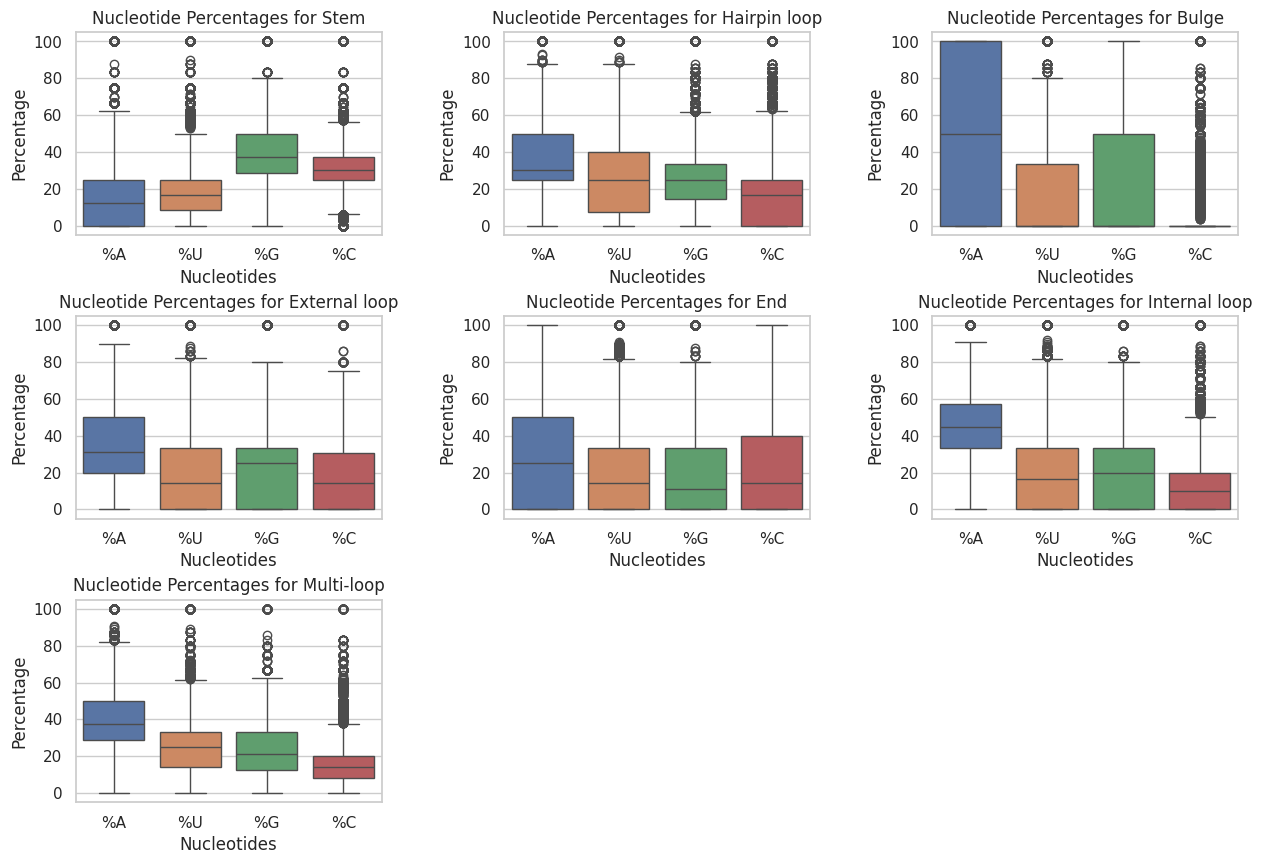

In [ ]:
# Number of subplots
n = len(dfs)
cols = 3  # Choose the number of columns based on your preference or display width
rows = n // cols + (n % cols > 0)  # Calculate number of rows needed to accommodate all subplots

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))  # Adjust size to your preference
fig.subplots_adjust(hspace=0.4, wspace=0.4)  # Adjust spacing between plots

# Flatten the axes array if it's 2D for easier iteration
axes = axes.flatten()

# Iterate over each substructure DataFrame and plot
for i, (sub, df) in enumerate(dfs.items()):
    # Use substructure_names to get the descriptive name
    sns.boxplot(data=df, ax=axes[i])
    axes[i].set_title(f'Nucleotide Percentages for {substructure_names.get(sub, "Unknown")}')
    axes[i].set_xlabel('Nucleotides')
    axes[i].set_ylabel('Percentage')

# If there are any leftover axes, turn them off
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

Our analysis reveals fairly uniform distributions of nucleotides across most RNA secondary structures, with some notable exceptions. In stems, guanine (G) is the predominant nucleotide, which aligns with its role in forming stable G-C base pairs. Conversely, adenine (A) is more prevalent in internal loops, external loops, and multi-loops, possibly due to its compatibility with diverse and less stable interactions. Interestingly, in bulges, cytosine (C) is notably less common, while adenine (A) again appears as the most frequent nucleotide.

# Part 4: Predicting the Number of Substructure

The first problem statement we want answer is a regression task: Predicting the number of substructures from a given RNA sequences.

The **input** to these models will be RNA sequences and **output** will be number of the 7 secondary substructures : stem, bulge, end, multi loop, external loop, internal loop, hairpin loop.

We start with building a **baseline neural network model** and perform hyper-parameter tuning to find the best model parameters.

The next step is building an advanced model with the ability to capture the sequential information of the RNA data. We attempt to use **recurrent neural networks** with LSTM units for this purpose.

## 4.1 Data Preprocessing

Traning a base line model using one-hot coded RNA sequences as input and number of secondary sequences of all kinds as output.
The first step is to get the RNA sequence ready for input to the machine learning models.

https://www.tensorflow.org/guide/keras/understanding_masking_and_padding

1. As a first attempt at simplest implementation, we use **one-hot-encoded** technique to convert RNA sequence input to vectors.
2. Since the fraction of RNA sequences with ambiguous nucleotides is not a significant fraction of the total data size (only 5%), we can safely use a zero vector to **mask** the ambiguous nucleotides. We eventually cleaned this data in the section 2.2
3. Since our input contains RNA sequences of different lengths, we need to manipulate the one hot encoding to have a uniform size for all inputs. This can be done by **padding**. Padding is a special type of masking, in which, the masked steps are at the start or the end of a sequence. We use a zero vector for padding.



In [ ]:
def one_hot_encoded_rna(sequence, max_length):
    mapping = {'A': [1, 0, 0, 0], 'U': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'C': [0, 0, 0, 1]}
    zero_vector = [0, 0, 0, 0]  # Vector used masking in places of ambiguous nucleotides in a sequence and for padding at the end of the sequence to make all sequence lengths equal
    encoded = [mapping.get(nucleotide, zero_vector) for nucleotide in sequence]
    return np.array(encoded + [zero_vector] * (max_length - len(encoded)))

4. Considering the wide range of distribution of lengths of the RNA sequence,it might not be a good idea to pad all sequence inputs with zero vector to reach the max length. It might be better to **find an optimum cutoff for RNA sequence length** that we will consider for this model.

In [ ]:
# Calculate maximum sequence length
longest_sequence = max(rna_df['sequence'].str.len())
print("Maximum length of RNA sequence in the input data:", longest_sequence)

Maximum length of RNA sequence in the input data: 4381


By looking at the distribution of the length of RNA sequence in the EDA section 3.1, it's reasonable to set a **length cutoff** of 500 nucelotides so that we don't have to provide excessive padding for only a few outliers that are very long.

In [ ]:
max_length=500

In [ ]:
rna_df = rna_df[rna_df['length'] <= max_length]
rna_df.reset_index(inplace=True)

In [ ]:
# Applying one-hot-encoding to all sequences in rna_df

rna_df['encoded'] = rna_df['sequence'].apply(lambda x: one_hot_encoded_rna(x, max_length))
encoded_sequences = np.array(rna_df['encoded'].tolist())

In [ ]:
rna_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83054 entries, 0 to 83053
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   index                  83054 non-null  int64 
 1   rna_name               83054 non-null  object
 2   length                 83054 non-null  int64 
 3   sequence               83054 non-null  object
 4   dot_bracket_structure  83054 non-null  object
 5   S                      83054 non-null  int64 
 6   H                      83054 non-null  int64 
 7   M                      83054 non-null  int64 
 8   I                      83054 non-null  int64 
 9   B                      83054 non-null  int64 
 10  X                      83054 non-null  int64 
 11  E                      83054 non-null  int64 
 12  encoded                83054 non-null  object
dtypes: int64(9), object(4)
memory usage: 8.2+ MB


## 4.2 Baseline Model: Feedforward Neural Network (FNN)

We initially fit a simple feedforward neural network model on the cleaned and pre-processed dataset with ~ 83000 sequences (data set size)

Simple neural networks do not take into account the complexity of sequential data like RNAs. Convolutional neural networks or recurrent neural networks do better with sequential data in general.

In [ ]:
# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(encoded_sequences, rna_df[['S', 'H', 'M', 'I', 'B', 'X', 'E']].values, test_size=0.30, random_state=42)


In [ ]:
# Neural network model
model = Sequential([
    Flatten(input_shape=(max_length, 4)), # Input layer for one-hot-encoded RNA sequences
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(7, activation='relu')  # Output layer for S, H, M, I, B, X, E
])

model.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error']) #we choose mse as loss because we a building a regression model

**Model fitting:**
1. We use adam optimizer with mean squared error loss function while also generating mean average error metric for every epoch. This metric is calculated on a validation set (20% of the x_train data) after every epoch. This will help us monitor the training progress by quantifying validation loss at every epoch.
2. We plot the trend in training and validation loss at each epoch and also plot distribution of predcited and actual values for each substructure.

In [ ]:
# Train the model and save training and validation results in history
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2 )

Epoch 1/50
727/727 [==============================] - 5s 4ms/step - loss: 1.3012 - mean_absolute_error: 0.5944 - val_loss: 1.0666 - val_mean_absolute_error: 0.5214
Epoch 2/50
727/727 [==============================] - 3s 4ms/step - loss: 0.9677 - mean_absolute_error: 0.4918 - val_loss: 0.9991 - val_mean_absolute_error: 0.4734
Epoch 3/50
727/727 [==============================] - 3s 4ms/step - loss: 0.8303 - mean_absolute_error: 0.4498 - val_loss: 0.9335 - val_mean_absolute_error: 0.4565
Epoch 4/50
727/727 [==============================] - 3s 4ms/step - loss: 0.7238 - mean_absolute_error: 0.4185 - val_loss: 0.9052 - val_mean_absolute_error: 0.4394
Epoch 5/50
727/727 [==============================] - 3s 4ms/step - loss: 0.6330 - mean_absolute_error: 0.3942 - val_loss: 0.8965 - val_mean_absolute_error: 0.4493
Epoch 6/50
727/727 [==============================] - 3s 4ms/step - loss: 0.5578 - mean_absolute_error: 0.3716 - val_loss: 0.8788 - val_mean_absolute_error: 0.4236
Epoch 7/50
727/7

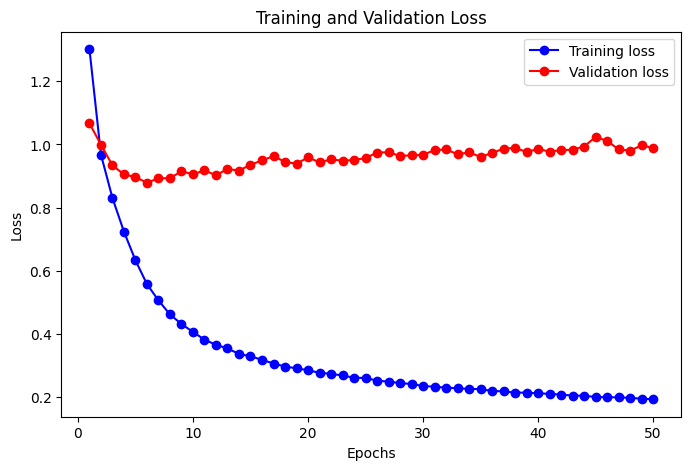

In [ ]:
# Extracting loss and validation loss from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Creating epochs array
epochs = range(1, len(train_loss) + 1)

# Plotting Loss and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

The training loss is exponentially reducing through the epochs. However, the validation loss plateaus around 10 epochs. We can conclude that the model is trained the best it can by 10 epochs, further training is not adding any value to the model.

In [ ]:
# Make prediction on the test set
predictions = model.predict(X_test)

779/779 [==============================] - 1s 1ms/step


In [ ]:
# Evaluate the model's performance
mse = tf.keras.losses.MeanSquaredError()
test_mse = mse(y_test, predictions).numpy()
print(f"Overall Test MSE for predictions on all seven substructures: {test_mse}") # this includes overall mse for predictions on all seven substructures

Overall Test MSE for predictions on all seven substructures: 0.9402124285697937


In order to asses the correctness of the model, we calculate the mean squared error, mean absolute error and R2 score on 30% of the data selected as the test set. We plot the distribution of the predicted and actual values of the number of the seven substructures.  

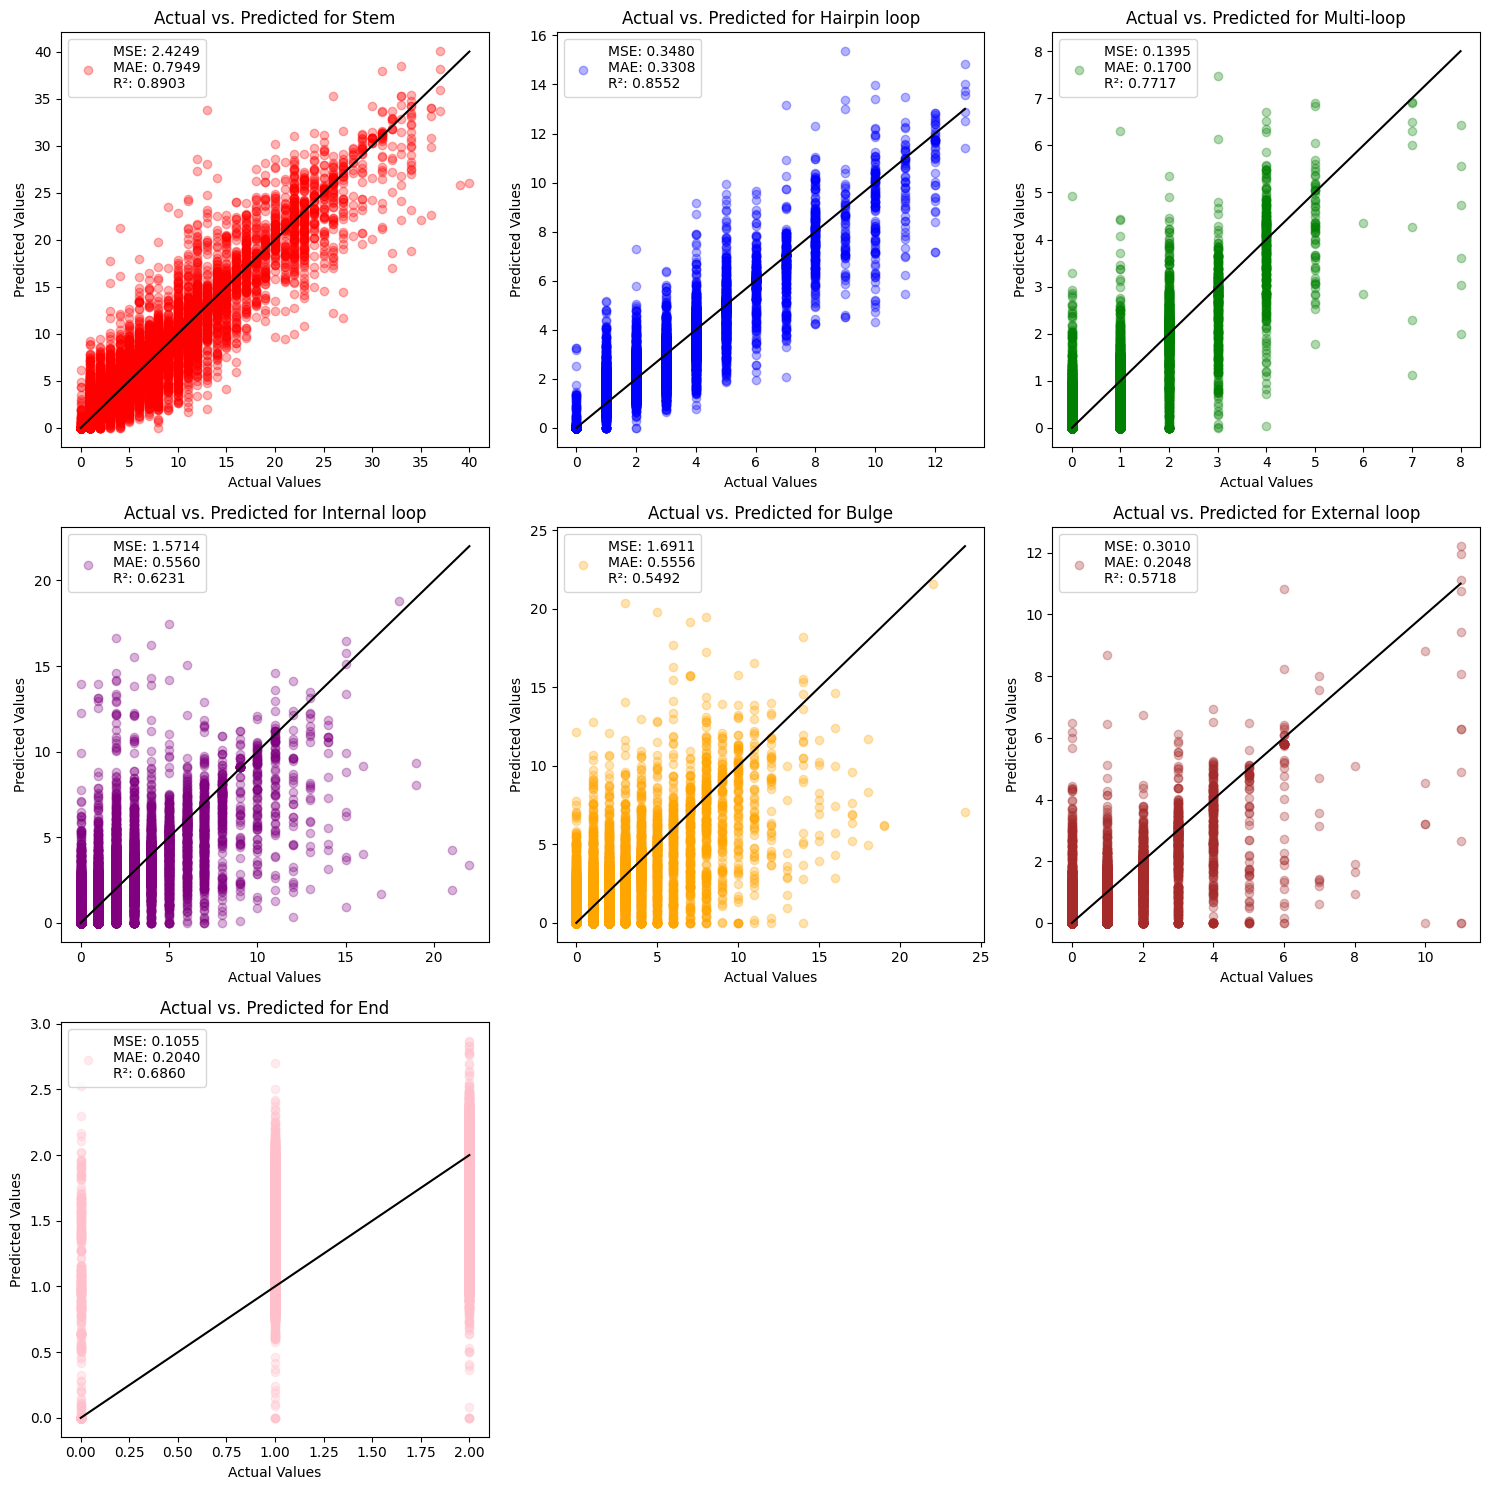

In [ ]:
substructure_names = {
    'S': 'Stem',
    'H': 'Hairpin loop',
    'M': 'Multi-loop',
    'I': 'Internal loop',
    'B': 'Bulge',
    'X': 'External loop',
    'E': 'End'
}

# Initialize the plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

substructures = ['S', 'H', 'M', 'I', 'B', 'X', 'E']
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink']

for i, substructure in enumerate(substructures):
    actual = y_test[:, i]
    predicted = predictions[:, i]

    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    ax = axes[i]
    scatter = ax.scatter(actual, predicted, alpha=0.3, color=colors[i])
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.set_title(f'Actual vs. Predicted for {substructure_names[substructure]}')
    ax.plot([np.min(actual), np.max(actual)], [np.min(actual), np.max(actual)], color='black')  # Diagonal line

    # Legend with performance metrics
    legend_label = f'MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
    ax.legend([scatter], [legend_label], loc='upper left')

# Hide the last subplot (unused)
axes[-1].axis('off')  # Hide the 9th subplot (bottom right)
axes[-2].axis('off')  # Hide the 8th subplot (bottom center)

plt.tight_layout()
plt.show()

The black diagonal (x = y) line represents the ideal scenario where all predictions match the actual values. The individual predictions are marked as colored circles for each plot. The mean squared error, mean absolute error and R2 score are reported on each plot for the respective substructures.

**Observations:**

1. Stem, hairpin and multiloop are predicted with most accuracy (R2 score ~ 0.77-0.9)
2. Internal loop and ends predictions show lesser accuracy (R2 score ~ 0.62-0.68)
3. External loops and bulges are predicted with the lowest accuracy (R2 score ~ 0.55 - 0.57)

This could be due to:
1. Under-representation of external loops and bulges in the RNA sequence.
2. Inability of the simple feed-forward neural network to capture the sequential RNA nucleotide information. We will attempt to train a recurrent neural network using the same input and output features.


We also plot the distribution of prediction errors for all seven secondary structures using histograms.

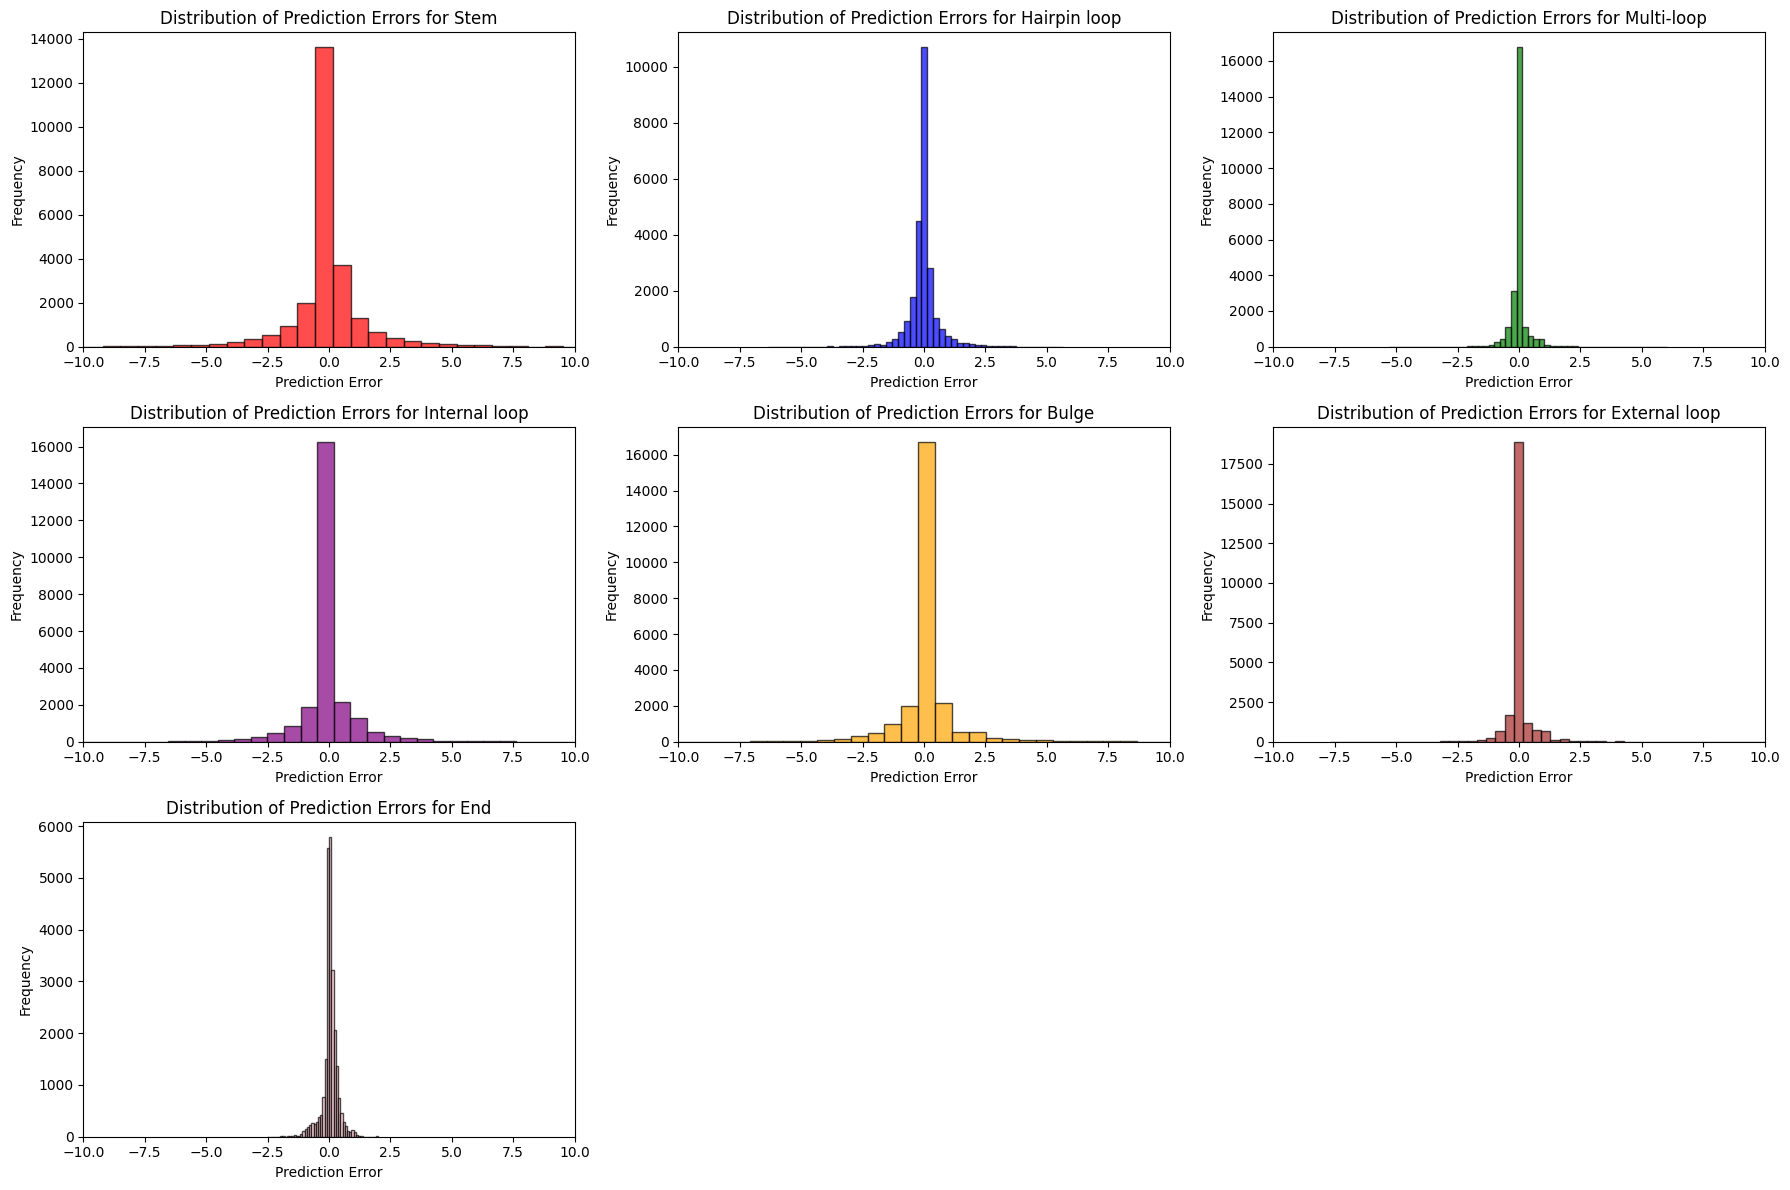

In [ ]:
# Initialize the figure for multiple subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 12))  # Adjusted layout for 7 substructures (leaving some empty)
axes = axes.flatten()

substructures = ['S', 'H', 'M', 'I', 'B', 'X', 'E']
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink']

for i, substructure in enumerate(substructures):
    actual = y_test[:, i]
    predicted = predictions[:, i]
    errors = actual - predicted

    ax = axes[i]
    ax.hist(errors, bins=50, alpha=0.7, color=colors[i], edgecolor='black')
    ax.set_xlim([-10, 10])
    ax.set_xlabel('Prediction Error')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of Prediction Errors for {substructure_names[substructure]}')

# Hide unused subplots
for j in range(i + 1, 9):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

The prediction errors show a normal distribution. The spread is widest for stem, internal loop and narrower for bulges, ends, external loop, hairpin loop, multi-loop.

**Model evaluation:**

The model was fit and a mean squared error across all test predictions was calculated to be **0.94** We wanted to get an understanding of how good or bad this value is.
1. As a simple check for the performance of our preliminary neural network modeling attempt, we decided to compare the NN based test MSE with simple mean and median predictions from the chosen test and training data sets.
2. We observe that the NN performs much better than simple mean and median regression.

In [ ]:
# Find mean and median of the training data set
mean = np.mean(y_train, axis=0)
median = np.median(y_train, axis=0)

# Predict using the mean and median for the test set
mean_predictions = np.tile(mean, (len(y_test), 1))
median_predictions = np.tile(median, (len(y_test), 1))

# Calculate MSE for mean and median models
mse_mean = mean_squared_error(y_test, mean_predictions)
mse_median = mean_squared_error(y_test, median_predictions)

print(f"Overall Test MSE for predictions on all seven substructures (Mean Model): {mse_mean}")
print(f"Overall Test MSE for predictions on all seven substructures (Median Model): {mse_median}")


Overall Test MSE for predictions on all seven substructures (Mean Model): 4.868706796056554
Overall Test MSE for predictions on all seven substructures (Median Model): 5.557146870467093


The MSE for Mean and Median models are **1 order of magnitude** larger than the MSE calculated from neural network predictions. This validates that our Neural Network model is making significantly better predictions.  

## 4.3 Hyperparameter Tuning on FNN

We have built a feedforward neural network to predict number of substructures in an RNA sequence. We now want to improve the model by choosing the better parameters for the model. We vary the number of neurons in the hidden layers of the neural network architecture and vary the optimization learning rate. The loss function used is mean squared error as this is a regression task.

We use keras tuner library for randomized search.
https://www.tensorflow.org/tutorials/keras/keras_tuner

1. We use a train-test split on the cleaned data set.
2. Training data set is further split to train (80%) and validation (20%) set.
3. The objective for hyperparameter tuning is minimizing loss on the validation set.
4. The final test MSE loss for the best model is calculated.

In [ ]:
class RNASeqModel(HyperModel):
    def __init__(self, max_length):
        self.max_length = max_length

    def build(self, hp):
        model = Sequential([
            Flatten(input_shape=(self.max_length, 4)),
            Dense(units=hp.Int('layer1', min_value=32, max_value=128, step=32), activation='relu'),
            Dense(units=hp.Int('layer2', min_value=16, max_value=64, step=16), activation='relu'),
            Dense(7, activation='relu') # regression task
        ])
        model.compile(
            optimizer=Adam(hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
            loss='mse'
        )
        return model


In [ ]:
max_length = 500  #chosen based on distribution of RNA sequence length in the dataset (explained in the section 4.1)

hypermodel = RNASeqModel(max_length=max_length)

tuner = RandomSearch(
    hypermodel,
    objective='val_loss',
    max_trials=10,  # Set a reasonable number of trials
    executions_per_trial=2,  # Number of models to train for each trial
    directory='/content/drive/MyDrive/CIS_545_fin_proj/hyperparameter_tuning_data',
    project_name='rna_seq'
)

# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(encoded_sequences, rna_df[['S', 'H', 'M', 'I', 'B', 'X', 'E']].values, test_size=0.30, random_state=42)

# Perform hyperparameter tuning
tuner.search(X_train, y_train, epochs=50, validation_split=0.2)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Making predictions on the test data
predictions = best_model.predict(X_test)


Reloading Tuner from /content/drive/MyDrive/CIS_545_fin_proj/hyperparameter_tuning_data/rna_seq/tuner0.json
779/779 [==============================] - 1s 2ms/step


In [ ]:
# Print the architecture of the best model
best_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 2000)              0         
                                                                 
 dense (Dense)               (None, 128)               256128    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 7)                 455       
                                                                 
Total params: 264839 (1.01 MB)
Trainable params: 264839 (1.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Evaluate the model's performance
mse = tf.keras.losses.MeanSquaredError()
test_mse = mse(y_test, predictions).numpy()
print(f"Test MSE: {test_mse}")

Test MSE: 0.7564265727996826


The hyperparameter tuning exercise establihes the best model:

The mean squared error(MSE) for test data is calculated to be 0.76. This is a 23.6% reduction in the value when compared to the original test MSE of 0.94.

## 4.4 Discussion on Performance of Baseline Model

The feedforward neural network gives mixed R2 results for the seven substructures. R2 scores lie between 0.5 - 0.9.

Factors to consider with this model:

**Problem 1 (Potential overfitting due to similarity in input sequence data)** : The bpRNA dataset has over 100,000 sequences. After data-cleaning and constraining the length of the RNA sequences to 500 nucleotides, we are using ~83,000 sequences. There might be several sequences that have significant overlap/similarity with each other. This could result in biased training and overfitting, which could give overall lower loss on both the training and test for some over-represented substructures.

**Solution step 1:** We can use a different source of RNA sequence data to check the performance of model on **new**  RNA sequences with negligible similarity with our bpRNA data. If the results are not good, we can conclude that similiarity in the data set used for training is biasing the model.

**Solution step 2:** This can be improved by using biological understanding to reduce the size of the training data set by eliminating similar sequences. Based on our literature survey, data-driven models usually use 60-80% elimination cutoff for similarity in sequences.


**Problem 2 (Simple FNNs cannot capture the complexity of sequential data like RNA or DNA):** We use one hot encoding to convert nucloetide sequences to numerical inputs for our FNN model architecture. However, the sequence of occuurence of these nucleotides is very important to accurately capture the complex and important model features.

**Solution step:** Build advanced models like **Recurrent Neural Networks** with better embedding techniques and LSTM (Long short-term memory) units that can effectively capture sequence based memory and its effects on features.  

## 4.5 Advanced Model: Recurrent Neural Network

We are building a recurrent neural network with Long Short-Term Memory (LSTM) units that have the ability to better retain long-term dependencies in sequence data.  

**Data preprocessing for RNN input:**
For the recurrent neural network, we are using embedding layers instead of one-hot encoding done in the previous baseline model.
We will map the 4 nucleotides to 4 different integer values (A=1, C=2, G=3, U=4).

In [ ]:
# Function to integer-encode RNA sequences
def integer_encode_rna(sequence):
    mapping = {'A': 1, 'C': 2, 'G': 3, 'U': 4}
    return np.array([mapping[x] for x in sequence])


In [ ]:
rna_df = rna_df[rna_df['length'] <= 500]
rna_df.reset_index(inplace=True)

In [ ]:
rna_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83054 entries, 0 to 83053
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   level_0                83054 non-null  int64 
 1   index                  83054 non-null  int64 
 2   rna_name               83054 non-null  object
 3   length                 83054 non-null  int64 
 4   sequence               83054 non-null  object
 5   dot_bracket_structure  83054 non-null  object
 6   S                      83054 non-null  int64 
 7   H                      83054 non-null  int64 
 8   M                      83054 non-null  int64 
 9   I                      83054 non-null  int64 
 10  B                      83054 non-null  int64 
 11  X                      83054 non-null  int64 
 12  E                      83054 non-null  int64 
 13  encoded                83054 non-null  object
dtypes: int64(10), object(4)
memory usage: 8.9+ MB


In [ ]:
integer_rna_sequences = rna_df['sequence'].apply(integer_encode_rna).tolist()


Input sequences are of unequal lengths, so we need to pad the inputs such that their length is the same. We do that by padding with 0s at the end of the sequences upto a maximum length of 500.

In [ ]:
input_padded = pad_sequences(integer_rna_sequences, padding='post')

In [ ]:
input_padded[0] # sample padded RNA sequence on integer embedded nucleotides

array([2, 3, 3, 2, 3, 2, 1, 4, 4, 1, 3, 2, 4, 1, 3, 4, 4, 3, 3, 4, 3, 1,
       3, 3, 4, 1, 1, 2, 3, 3, 2, 4, 2, 1, 2, 2, 1, 1, 3, 3, 2, 1, 1, 2,
       3, 1, 4, 3, 2, 3, 4, 1, 3, 2, 2, 3, 1, 2, 2, 4, 3, 1, 3, 1, 3, 3,
       3, 4, 3, 1, 4, 2, 3, 3, 2, 2, 1, 2, 3, 2, 4, 3, 3, 1, 1, 2, 4, 3,
       1, 3, 1, 2, 1, 2, 3, 3, 2, 2, 2, 1, 3, 1, 2, 4, 2, 2, 4, 1, 2, 3,
       3, 3, 1, 3, 3, 2, 1, 3, 2, 1, 3, 4, 1, 3, 3, 3, 1, 1, 2, 2, 4, 4,
       2, 2, 3, 2, 1, 1, 4, 3, 3, 1, 2, 3, 1, 1, 1, 3, 4, 2, 4, 3, 1, 2,
       3, 3, 1, 3, 2, 1, 1, 2, 3, 2, 2, 3, 2, 3, 4, 3, 1, 3, 4, 3, 1, 4,
       3, 1, 1, 3, 3, 4, 4, 4, 4, 2, 3, 3, 1, 4, 2, 3, 4, 1, 1, 1, 1, 2,
       4, 2, 4, 3, 4, 4, 3, 4, 4, 1, 3, 3, 3, 1, 1, 3, 1, 1, 2, 1, 1, 3,
       4, 3, 4, 3, 1, 3, 1, 3, 4, 1, 1, 2, 4, 3, 2, 4, 2, 1, 2, 1, 2, 2,
       4, 4, 3, 1, 2, 3, 3, 4, 1, 2, 2, 4, 1, 1, 2, 2, 1, 3, 1, 1, 1, 3,
       2, 2, 1, 2, 3, 3, 2, 4, 1, 1, 2, 4, 1, 2, 3, 4, 3, 2, 2, 1, 3, 2,
       1, 3, 2, 2, 3, 2, 3, 3, 4, 1, 1, 4, 1, 2, 3,

In [ ]:
len(input_padded[0]) # final length of all input sequences is 500

500

In [ ]:
# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(input_padded, rna_df[['S', 'H', 'M', 'I', 'B', 'X', 'E']].values, test_size=0.3, random_state=42)

In [ ]:
#RNN model architecture
model = Sequential([
    Embedding(input_dim=5, output_dim=8, input_length=X_train.shape[1]),  # input dimensions - 4 nucleotides + 1 (padding with 0), output-dim -> each integer converted to an 8 dimensional vector to capture additional complexity better than one hot encoding
    LSTM(64, return_sequences=True), # first recurrent layer using LSTM, this returns sequence information to the next LSTM unit
    LSTM(32), # this returns learnt features to the next connected dense layer
    Dense(32, activation='relu'), # relu activation captures non-linearity in the data
    Dense(7, activation='relu')  # final layer with 7 categories corresponding to the 7 substructures
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])  #we choose mse as loss because we a building a regression model




**Model fitting:**
1. We use adam optimizer with mean squared error loss function while also generating mean average error metric for every epoch. This metric is calculated on a validation set (20% of the x_train data) after every epoch. This will help us monitor the training progress by quantifying validation loss at every epoch.
2. We plot the trend in training and validation loss at each epoch and also plot distribution of predcited and actual values for each substructure.

In [ ]:
# Train the model and capture training and validation loss at every epoch
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

Epoch 1/20
727/727 [==============================] - 29s 35ms/step - loss: 5.2552 - mean_absolute_error: 1.1769 - val_loss: 5.4668 - val_mean_absolute_error: 1.1916
Epoch 2/20
727/727 [==============================] - 25s 34ms/step - loss: 5.1423 - mean_absolute_error: 1.1666 - val_loss: 5.4676 - val_mean_absolute_error: 1.1774
Epoch 3/20
727/727 [==============================] - 25s 34ms/step - loss: 5.1423 - mean_absolute_error: 1.1661 - val_loss: 5.4651 - val_mean_absolute_error: 1.1928
Epoch 4/20
727/727 [==============================] - 25s 34ms/step - loss: 5.1419 - mean_absolute_error: 1.1665 - val_loss: 5.4741 - val_mean_absolute_error: 1.1719
Epoch 5/20
727/727 [==============================] - 25s 34ms/step - loss: 5.1414 - mean_absolute_error: 1.1664 - val_loss: 5.4689 - val_mean_absolute_error: 1.1784
Epoch 6/20
727/727 [==============================] - 25s 34ms/step - loss: 5.1415 - mean_absolute_error: 1.1660 - val_loss: 5.4691 - val_mean_absolute_error: 1.1803
Epoc

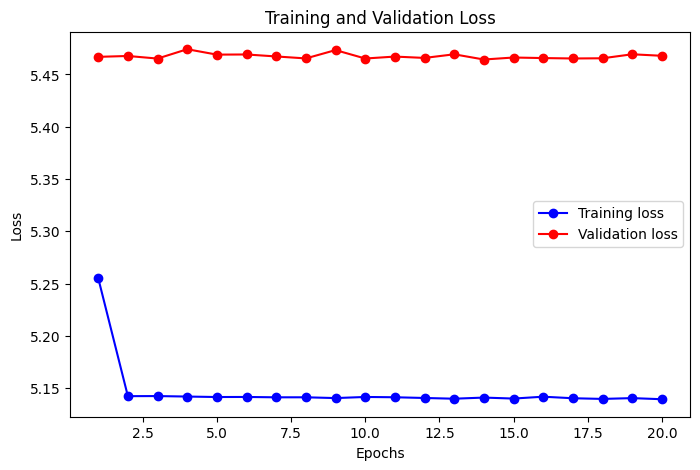

In [ ]:
# Extracting loss and validation loss from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# x axis - epochs
epochs = range(1, len(train_loss) + 1)

# Plotting Loss and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Though the training loss is minimized through 20 epochs, the validation loss remains at a somewhat constant higher loss value. This tells us that the model training is not improving with the epochs.

**Possible explanation for this behaviour:**

Though the RNN is able to capture sequential information in the RNA sequence, the used trainind data is not perfect for a regression task. There are several sequences in our training data that have significant similarity with each other. This is leading to over-fitting of a few type of substructures and underfitting of others. The overall means sqaured loss calculated for the validation data set is thus stagnant.

A possible future direction could be further cleaning and constraining the data set to remove sequences which as similar above a certrain threshold. It would be a good exercise to conduct a paramter scan over the % similarity threshold, to understand how distinct the training data should be, in order to get the best model performances.

In [ ]:
#predictions on the test set
predictions = model.predict(X_test)

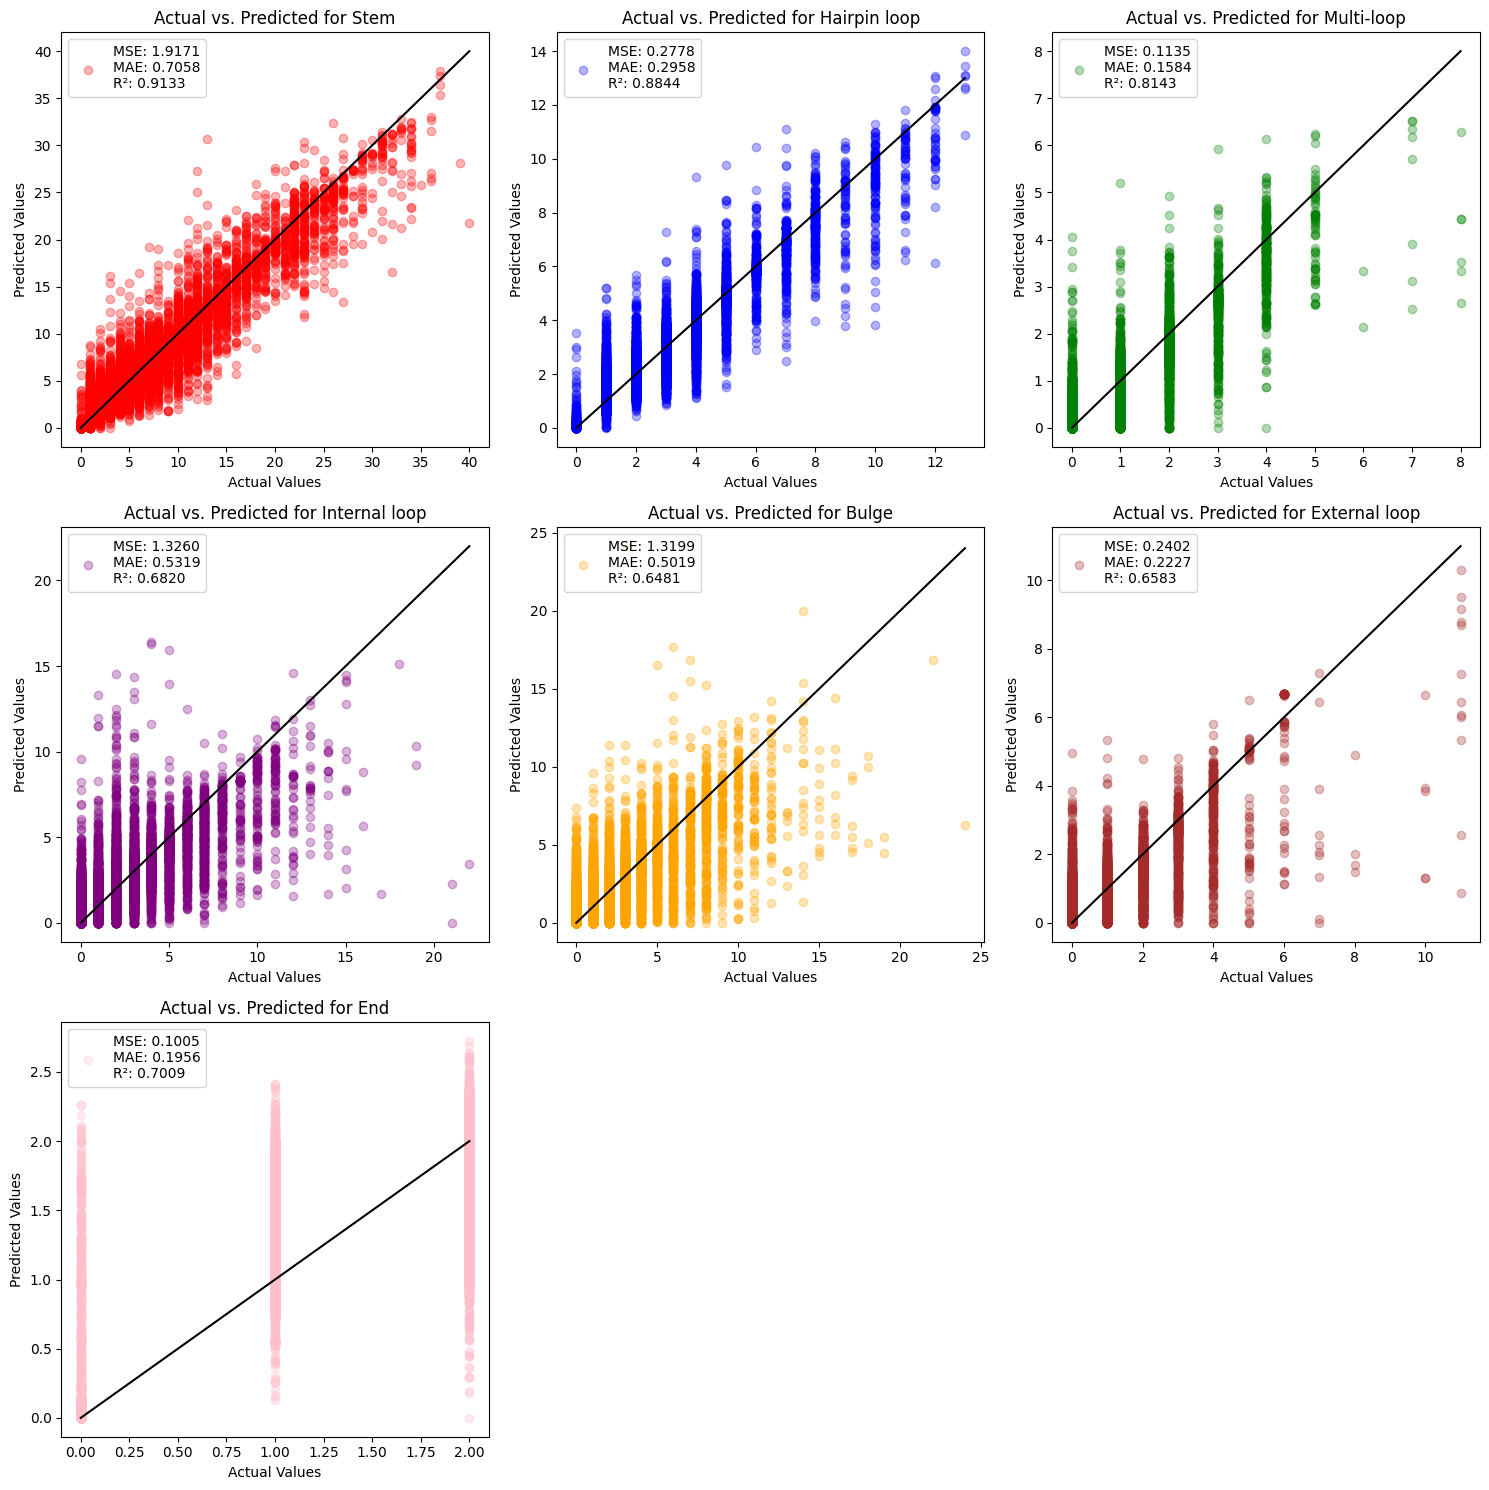

In [ ]:
substructure_names = {
    'S': 'Stem',
    'H': 'Hairpin loop',
    'M': 'Multi-loop',
    'I': 'Internal loop',
    'B': 'Bulge',
    'X': 'External loop',
    'E': 'End'
}

# Initialize the plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjusted layout for 7 substructures (leaving one empty)
axes = axes.flatten()

substructures = ['S', 'H', 'M', 'I', 'B', 'X', 'E']
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink']

for i, substructure in enumerate(substructures):
    actual = y_test[:, i]
    predicted = predictions[:, i]
    # Making predictions on the test data and calculate mse, mae, r2
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    ax = axes[i]
    scatter = ax.scatter(actual, predicted, alpha=0.3, color=colors[i])
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.set_title(f'Actual vs. Predicted for {substructure_names[substructure]}')  # Use full name
    ax.plot([np.min(actual), np.max(actual)], [np.min(actual), np.max(actual)], color='black')  # Diagonal line

    # Legend with performance metrics
    legend_label = f'MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
    ax.legend([scatter], [legend_label], loc='upper left')

# Hide the last subplot (unused)
axes[-1].axis('off')  # Hide the 9th subplot (bottom right)
axes[-2].axis('off')  # Hide the 8th subplot (bottom center)

plt.tight_layout()
plt.show()

## 4.6 Discussion on Performance of Advanced Model

In order to capture the complexity of sequential information of the RNA data, we chose to implement a recurrent neural network for our regression task. The R2 scores for all substructure predictions are better for the RNN model as compared to the FNN. This agrees with our expectation that RNN is more capable of capturing contextual information than our baseline FNN model.

However, we find that the recurrent neural network does not perform well on the validation splits across training epochs.

Our **hypothesis** is that the similiarity in RNA sequences in the training data results in poor model performance. The biased training data has over-representation of certain sequences as compared to others.

In order to test this, we propose the following as **future directions**:

1. Cleaning and constraining the data set to remove sequences which are similar above a certrain threshold.

2. It would be a good exercise to conduct a parameter scan over the % similarity threshold, to understand how distinct the training data should be, in order to get the best model performances.


# Part 5: Predicting the Secondary Structure of RNA

In this section, we aim to build a model to predict RNA secondary structures based on their sequence data, utilizing a deep learning approach. RNA sequences consist of nucleotides (adenine, uracil, guanine, and cytosine), and the goal is to predict the corresponding structure at each position in the sequence, which can be represented as dot-bracket notation (where "." signifies unpaired nucleotides and paired nucleotides are denoted by matching parentheses). This is a **multiclass classification problem**.

## 5.1 Mini-EDA and Data Proprocessing

First, let's determine all of the unique characters used in the dot-bracket structures.

In [ ]:
# Concatenate all strings in the 'dot_bracket_structure' column
all_structures = ''.join(rna_df['dot_bracket_structure'])

# Use a set to find all unique characters in the concatenated string
unique_characters = set(all_structures)

# Print the unique characters
print("Unique characters in dot_bracket_structure:", unique_characters)

Unique characters in dot_bracket_structure: {'.', '>', '(', '[', ')', 'a', ']', '}', 'A', '{', '<'}


Since we have 11 distinct characters, it's a good idea to look at the prevalence of these characters to address potential **class imbalance**.

In [ ]:
from collections import Counter

all_structures = ''.join(rna_df['dot_bracket_structure'])
char_counts = Counter(all_structures)

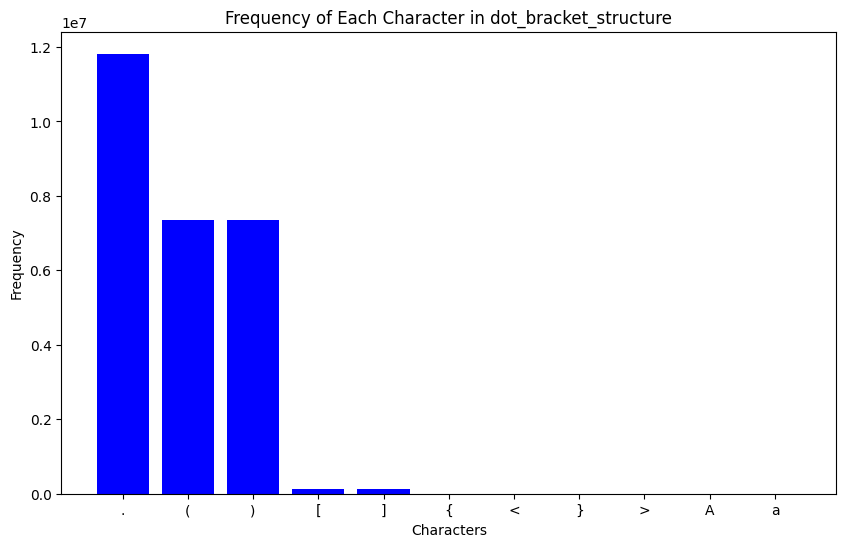

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.bar(char_counts.keys(), char_counts.values(), color='blue')
plt.title('Frequency of Each Character in dot_bracket_structure')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()

We observe that the characters `.`, `(`, and `)` are predominant.

To simplify our analysis of the RNA secondary structures, we will focus on the first three primary characters used to denote structure in the dot-bracket notation. This means that we are simplyfing our task to predicting only RNA secondary structures that can be represented by only *dots* and *round brackets*. Let's apply this filter to the dataset.

In [ ]:
# Keep only dot-bracket structure containing only ., (, and ).
def contain_only(sequence):
    forbid = ['[', ']', '{', '}', '<', '>', 'A', 'a']
    for i in sequence:
        if i in forbid:
            return False
    return True

In [ ]:
# Apply filter to retain . ( ) sequences
rna_simple_df = rna_df[rna_df['dot_bracket_structure'].apply(contain_only)].reset_index(drop=True)

Similarly, we learned from Figure 3.1 that RNA sequences are predominantly in the range of less than 500-nt long. Let's apply this cutoff to the dataset.

In [ ]:
# Calculate maximum sequence length
max_length = max(rna_simple_df['sequence'].str.len())
print("Maximum length of RNA sequence in the input data:", max_length)

Maximum length of RNA sequence in the input data: 4065


In [ ]:
# Apply the less than 500-nt filter to the dataset
rna_simple_df = rna_simple_df[rna_simple_df['length'] <= 500].reset_index(drop=True)

In [ ]:
max_length = max(rna_simple_df['sequence'].str.len())
print("Maximum length of RNA sequence in the input data:", max_length)

Maximum length of RNA sequence in the input data: 500


In [ ]:
rna_simple_df.head()

,rna_name,length,sequence,dot_bracket_structure,S,H,M,I,B,X,E
0,bpRNA_CRW_10162,466,CGCUGGCGGCGUGCCUAAUACAUGCAAGUCGAGCGAACAGAUAAGG...,.....(((((((((....(((.(((..(((..((((((.((..(((...,34,11,4,10,9,2,1
1,bpRNA_CRW_10284,312,CUCUGCACCUCCCGAGUGCUUGCACUCAAUUGGAAAGAGGAGUGGC...,(((..(((.....(((((....))))).....))..)))).........,20,8,2,4,6,1,1
2,bpRNA_CRW_10340,476,UAGAGUUUUGAUCCUGGCUCAGGAUGAACGCUGGCGGCGUGCCUAA...,...(((((.......))))).............(((((((((.......,32,12,4,8,8,3,1
3,bpRNA_CRW_10420,459,CCUAAUACAUGCAAGUCGAGCGAUCCUUUGACGUUAGCGGCGGACG...,(....(((.(((..(((..((((...........)))))))........,30,11,4,9,7,0,1
4,bpRNA_CRW_10437,494,GACGAACGCUGGCGGCGUGCCUAAUACAUGCAAGUAGAACGCUGAG...,...........(((((((((....(((.(((..(((..(((((.((...,34,11,4,11,8,1,2


In [ ]:
rna_simple_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78212 entries, 0 to 78211
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   rna_name               78212 non-null  object
 1   length                 78212 non-null  int64 
 2   sequence               78212 non-null  object
 3   dot_bracket_structure  78212 non-null  object
 4   S                      78212 non-null  int64 
 5   H                      78212 non-null  int64 
 6   M                      78212 non-null  int64 
 7   I                      78212 non-null  int64 
 8   B                      78212 non-null  int64 
 9   X                      78212 non-null  int64 
 10  E                      78212 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 6.6+ MB


## 5.2 Gated Recurrent Units (GRU) Network

We chose gated Recurrent Units (GRU) network for its capability to capture sequential data and context while being computationally simpler than other recurrent neural network architectures, such as Long Short-Term Memory (LSTM) networks.

Based on the above "mini-EDA," we redefined this predictive problem to be a three-class classification problem. Given an RNA sequence, each nucleotide is classified as one of the three classes: `.`, `(`, `)`, with each corresponding brackets denoting two paired bases.

### 5.2.1 Building and Training the Model

In this segment, we're setting up the preprocessing steps:

1. **Mapping to Integers**: Each nucleotide (A, U, G, C) and structural symbol (., (, )) in the RNA sequences is mapped to a unique integer. This transformation is required for converting the categorical data into a format that can be processed by machine learning models.

2. **Padding**: To ensure that all sequences have the same length, both the encoded RNA sequences and their structure annotations are padded. Sequences shorter than 500 are extended with zeros at the end, creating consistent input dimensions across all data samples.

In [ ]:
# Map nucleotides and structure symbols to integers
nucleotide_to_int = {'A': 1, 'U': 2, 'G': 3, 'C': 4}
structure_to_int = {'.': 1, '(': 2, ')': 3}

# Constants
MAX_LENGTH = 500
VOCAB_SIZE = len(nucleotide_to_int) + 1  # +1 for padding
STRUCTURE_CLASSES = len(structure_to_int) + 1  # +1 for padding

# Convert sequences and structures to integer encoding
rna_sequences_encoded = [[nucleotide_to_int[nt] for nt in seq] for seq in rna_simple_df['sequence']]
structures_encoded = [[structure_to_int[st] for st in struct] for struct in rna_simple_df['dot_bracket_structure']]

# Pad sequences to ensure uniform length
rna_sequences_padded = pad_sequences(rna_sequences_encoded, maxlen=MAX_LENGTH, padding='post', value=0)
structures_padded = pad_sequences(structures_encoded, maxlen=MAX_LENGTH, padding='post', value=0)

We divided the dataset into an 80% training set for initial model learning, a 10% validation set for preventing overfitting during training, and a 10% test set for an unbiased evaluation.

In [ ]:
# Split the data into training, validation, and test sets.
X_train, X_temp, y_train, y_temp = train_test_split(rna_sequences_padded, structures_padded, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Make sure that the dataset do not have NaN and Inf values
print("NaNs in training data:", np.isnan(rna_sequences_padded).any())
print("Infs in training data:", np.isinf(rna_sequences_padded).any())
print("NaNs in structure data:", np.isnan(structures_padded).any())
print("Infs in structure data:", np.isinf(structures_padded).any())

print("Unique labels:", np.unique(structures_padded))

NaNs in training data: False
Infs in training data: False
NaNs in structure data: False
Infs in structure data: False
Unique labels: [0 1 2 3]


**Model Architecture**

The model architecture is a deep learning model comprising an `Embedding` layer, a `GRU` layer, and a `TimeDistributed` layer that applies a Dense layer across every timestep:

1. **`Embedding` Layer**: This layer is used to convert integer-encoded nucleotide sequences into dense vectors. This transformation provides a more expressive representation of the nucleotides, capturing more nuanced information than mere integer codes.

2. **`GRU` Layer**: The GRU layer is chosen for its effectiveness in processing sequence data. It is useful for tasks where the context (i.e., the order and relationship between elements in the sequence) plays a critical role in accurate predictions. The return_sequences=True parameter ensures that the GRU outputs a sequence that matches the input sequence in length, which is necessary for making predictions at every position in the RNA sequence.

3. **`TimeDistributed` `Dense` Layer**: This layer applies a dense (fully-connected) neural network to each timestep independently. It is wrapped in a TimeDistributed wrapper to ensure that the same dense layer (with the same weights) is applied to each timestep, allowing the model to predict the structure at each position in the sequence. The softmax activation function is used in the dense layer to output a probability distribution over possible structure classes for each timestep.

In [ ]:
# Model
model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=10, mask_zero=True),
    GRU(64, return_sequences=True),
    TimeDistributed(Dense(STRUCTURE_CLASSES, activation='softmax'))
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train,
                    y_train[..., None], #  Structures need an extra dimension for compatibility with sparse_categorical_crossentropy
                    validation_data=(X_val, y_val),
                    batch_size=32,
                    epochs=20)

# Save the model to Drive
model.save('/content/drive/My Drive/CIS_545_fin_proj/part_5/gru5.2')

Epoch 1/20
1956/1956 [==============================] - 39s 17ms/step - loss: 0.8590 - accuracy: 0.5914 - val_loss: 0.7374 - val_accuracy: 0.6546
Epoch 2/20
1956/1956 [==============================] - 30s 16ms/step - loss: 0.7233 - accuracy: 0.6568 - val_loss: 0.6997 - val_accuracy: 0.6657
Epoch 3/20
1956/1956 [==============================] - 31s 16ms/step - loss: 0.6915 - accuracy: 0.6711 - val_loss: 0.6697 - val_accuracy: 0.6848
Epoch 4/20
1956/1956 [==============================] - 31s 16ms/step - loss: 0.6702 - accuracy: 0.6825 - val_loss: 0.6515 - val_accuracy: 0.6928
Epoch 5/20
1956/1956 [==============================] - 31s 16ms/step - loss: 0.6549 - accuracy: 0.6895 - val_loss: 0.6370 - val_accuracy: 0.6985
Epoch 6/20
1956/1956 [==============================] - 31s 16ms/step - loss: 0.6435 - accuracy: 0.6945 - val_loss: 0.6314 - val_accuracy: 0.7018
Epoch 7/20
1956/1956 [==============================] - 31s 16ms/step - loss: 0.6334 - accuracy: 0.6991 - val_loss: 0.6246 -

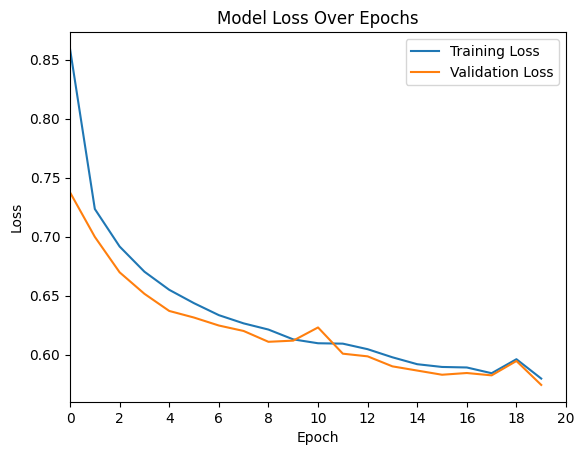

In [ ]:
# Plotting Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xlim([0, 20])
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # Set major tick locator to integer values
plt.show()

Training loss and validation loss are plotted together to detect potential overfitting (i.e., validation loss increases while training loss decreases). We observe that there are small spikes in validation loss at epoch 10 and epoch 18. However, both types of loss decrease overall, suggesting recovery after overfitting potentially due to adaptive learning rate (Adam).

Both losses seem to plateau at epoch 16, indicating the model has been sufficiently trained.

### 5.2.2 Evaluating the Model

To evaluate the performance of the model, we use metrics such as precision, recall, accuracy, and F1-score for individual classes.

In [ ]:
model = load_model('/content/drive/My Drive/CIS_545_fin_proj/part_5/gru5.2')

In [ ]:
# Make prediction
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=-1).flatten()
true_labels = y_test.flatten()

# Filter out padding value (0) if used
mask = true_labels > 0
predictions = predictions[mask]
true_labels = true_labels[mask]

# Accuracy
print("Accuracy:", accuracy_score(true_labels, predictions))

# Classification Report
print(classification_report(true_labels, predictions, target_names=['.', '(', ')']))

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predictions)
print(conf_matrix)

245/245 [==============================] - 3s 6ms/step
Accuracy: 0.7245021881252742
              precision    recall  f1-score   support

           .       0.70      0.86      0.77    379012
           (       0.76      0.57      0.65    184330
           )       0.78      0.60      0.68    184330

    accuracy                           0.72    747672
   macro avg       0.75      0.68      0.70    747672
weighted avg       0.73      0.72      0.72    747672

[[326979  28787  23246]
 [ 71498 104923   7909]
 [ 70685   3857 109788]]


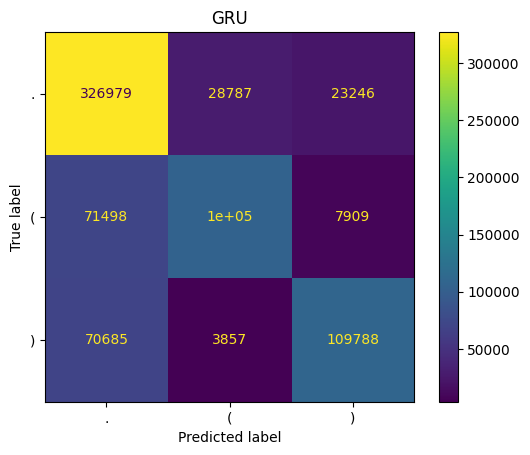

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['.','(',')'])
disp.plot()
plt.title("GRU")
plt.show()

We obtained decent recision, recall, accuracy, and F1-score for individual classes for this baseline model. To further improve this, we hypothesized that bidirectional GRU could be useful since it is capable of capturing contexual information in both forward and reverse directions of the RNA sequence.

## 5.3 Bidirectional Gated Recurrent Units (BGRU) Network

Bidirectional GRU is a variation of GRU that takes into account of both the forward and reverse directions. This version of GRU may be able to improve the prediction performance of the model.

### 5.3.1 Building and Training the Model

The model architecture is the same in Part 5.2, except that the GRU units are bidirectional.

In [ ]:
# Model
model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=10, mask_zero=True),
    Bidirectional(GRU(64, return_sequences=True)), # Bidirectional GRU
    TimeDistributed(Dense(STRUCTURE_CLASSES, activation='softmax'))
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train,
                    y_train[..., None], #  Structures need an extra dimension for compatibility with sparse_categorical_crossentropy
                    validation_data=(X_val, y_val),
                    batch_size=32,
                    epochs=20)

# Save the model
model.save('/content/drive/My Drive/CIS_545_fin_proj/part_5/bgru5.3')

Epoch 1/20
1956/1956 [==============================] - 57s 24ms/step - loss: 0.7762 - accuracy: 0.6255 - val_loss: 0.6703 - val_accuracy: 0.6785
Epoch 2/20
1956/1956 [==============================] - 44s 22ms/step - loss: 0.6368 - accuracy: 0.6920 - val_loss: 0.6043 - val_accuracy: 0.7081
Epoch 3/20
1956/1956 [==============================] - 44s 23ms/step - loss: 0.5903 - accuracy: 0.7170 - val_loss: 0.5677 - val_accuracy: 0.7281
Epoch 4/20
1956/1956 [==============================] - 44s 22ms/step - loss: 0.5631 - accuracy: 0.7310 - val_loss: 0.5451 - val_accuracy: 0.7397
Epoch 5/20
1956/1956 [==============================] - 44s 22ms/step - loss: 0.5422 - accuracy: 0.7418 - val_loss: 0.5453 - val_accuracy: 0.7431
Epoch 6/20
1956/1956 [==============================] - 44s 22ms/step - loss: 0.5280 - accuracy: 0.7496 - val_loss: 0.5163 - val_accuracy: 0.7563
Epoch 7/20
1956/1956 [==============================] - 44s 22ms/step - loss: 0.5134 - accuracy: 0.7573 - val_loss: 0.5039 -

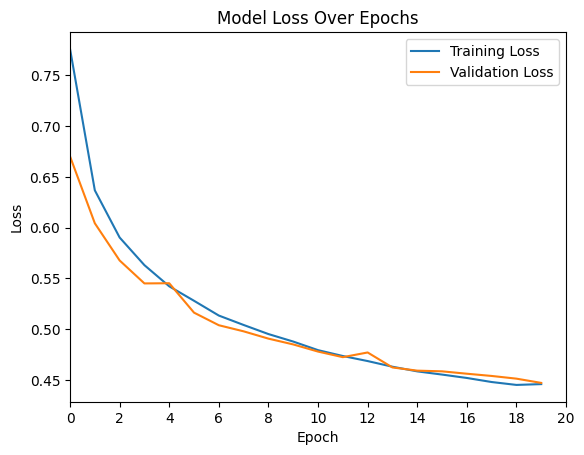

In [ ]:
# Plotting Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xlim([0, 20])
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # Set major tick locator to integer values
plt.show()

Both losses decrease across epochs, suggesting that the model is not overtrained.

### 5.3.2 Evaluating the Model

In [ ]:
model = load_model('/content/drive/My Drive/CIS_545_fin_proj/part_5/bgru5.3')

In [ ]:
# Make prediction
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=-1).flatten()
true_labels = y_test.flatten()

# Filter out padding value (0) if used
mask = true_labels > 0
predictions = predictions[mask]
true_labels = true_labels[mask]

# Accuracy
print("Accuracy:", accuracy_score(true_labels, predictions))

# Classification Report
print(classification_report(true_labels, predictions, target_names=['.', '(', ')']))

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predictions)
print(conf_matrix)

245/245 [==============================] - 4s 9ms/step
Accuracy: 0.7882065932654961
              precision    recall  f1-score   support

           .       0.78      0.84      0.81    379012
           (       0.79      0.74      0.76    184330
           )       0.80      0.73      0.76    184330

    accuracy                           0.79    747672
   macro avg       0.79      0.77      0.78    747672
weighted avg       0.79      0.79      0.79    747672

[[318801  31087  29124]
 [ 43855 135537   4938]
 [ 44514   4834 134982]]


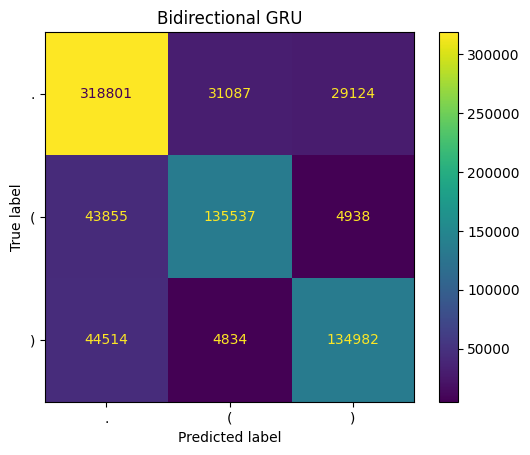

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['.','(',')'])
disp.plot()
plt.title("Bidirectional GRU")
plt.show()

For bidirectional GRU, we observe a significant increase in the predictive performance of the model.
- 13% increase in F1 score for `.`
- 17% increase in F1 score for `(`
- 12% increase in F1 score for `)`

This results agree with our hypothesis that capturing contextual sequence information from both forward and reverse direction is helpful in making accurate predictions.

### 5.3.3 Custom Loss Function to Penalize Unpaired Brackets

One limitation of both models above is that they fail to consider the external constraint dictating that each bracket must be paired with another closing bracket. This can result in unphysical representations of RNA structures, characterized by unpaired brackets. To address this issue, two strategies can be implemented:
1. **Train the model without the constraint**: Initially, the model is trained conventionally, without enforcing the pairing constraint. However, during structure determination from the probability matrix, instead of selecting the highest class probability for each nucleotide independently, a dynamic programming approach is employed. This approach ensures that the chosen class probabilities maximize the total sum of probabilities (i.e., scoring) while maintaining bracket pairing.
2. **Define a custom loss function**: Alternatively, a custom loss function can be implemented to penalize unpaired brackets directly. This entails augmenting the conventional loss function with an additional term, such as the difference between the total probabilities of opening and closing brackets. By incorporating this penalty term, the model learns to prioritize predictions that satisfy the bracket pairing constraint.

In this section, we implement the **second strategy**. First, let's define this custom loss function.

In [ ]:
def custom_loss(y_true, y_pred):
    # Extract mask from y_true, assuming padding is marked by zeros
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)  # Creates a mask of 1s for non-padded and 0s for padded values

    # Check if y_true has an extra dimension and squeeze if necessary
    if y_true.shape[-1] == 1:
        mask = tf.squeeze(mask, axis=-1)  # Only squeeze if there's an extra dimension of size 1

    # Calculate softmax to get probabilities
    softmax_pred = tf.nn.softmax(y_pred, axis=-1)

    # Apply mask to probabilities (broadcast mask to the last dimension of softmax_pred)
    masked_softmax = softmax_pred * mask[:, :, tf.newaxis]

    # Calculate penalties for open and close probabilities
    open_prob = tf.reduce_sum(masked_softmax[:, :, 2], axis=1)  # Index 2 for '(' probabilities
    close_prob = tf.reduce_sum(masked_softmax[:, :, 3], axis=1)  # Index 3 for ')' probabilities

    # Calculate imbalance penalty
    imbalance_penalty = tf.abs(open_prob - close_prob)

    # Calculate standard categorical crossentropy
    standard_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=False)

    # Apply mask to the loss
    masked_standard_loss = standard_loss * mask

    # Sum the standard loss and add the imbalance penalty
    final_loss = tf.reduce_sum(masked_standard_loss, axis=1) + 0.5 * imbalance_penalty

    # Return the mean of the final loss
    return tf.reduce_mean(final_loss)

Now we train the BGRU model from Part 5.3 using this custom loss function.

In [ ]:
# Model
model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=10, mask_zero=True),
    Bidirectional(GRU(64, return_sequences=True)),
    TimeDistributed(Dense(STRUCTURE_CLASSES, activation='softmax'))
])

# Compile the model but using the custom loss
model.compile(optimizer='adam', loss=custom_loss, metrics=['accuracy'])

# Train the model
history = model.fit(X_train,
                    y_train[..., None], #  Structures need an extra dimension for compatibility with sparse_categorical_crossentropy
                    validation_data=(X_val, y_val),
                    batch_size=32,
                    epochs=20)

Epoch 1/20
1956/1956 [==============================] - 56s 25ms/step - loss: 72.9051 - accuracy: 0.6329 - val_loss: 62.0688 - val_accuracy: 0.6827
Epoch 2/20
1956/1956 [==============================] - 46s 24ms/step - loss: 60.1758 - accuracy: 0.6978 - val_loss: 56.0030 - val_accuracy: 0.7161
Epoch 3/20
1956/1956 [==============================] - 46s 23ms/step - loss: 55.9384 - accuracy: 0.7216 - val_loss: 54.1411 - val_accuracy: 0.7246
Epoch 4/20
1956/1956 [==============================] - 46s 23ms/step - loss: 53.5919 - accuracy: 0.7344 - val_loss: 51.3600 - val_accuracy: 0.7426
Epoch 5/20
1956/1956 [==============================] - 46s 24ms/step - loss: 51.9262 - accuracy: 0.7444 - val_loss: 52.7153 - val_accuracy: 0.7394
Epoch 6/20
1956/1956 [==============================] - 46s 23ms/step - loss: 50.3805 - accuracy: 0.7532 - val_loss: 48.7976 - val_accuracy: 0.7580
Epoch 7/20
1956/1956 [==============================] - 46s 23ms/step - loss: 49.0217 - accuracy: 0.7607 - val_l

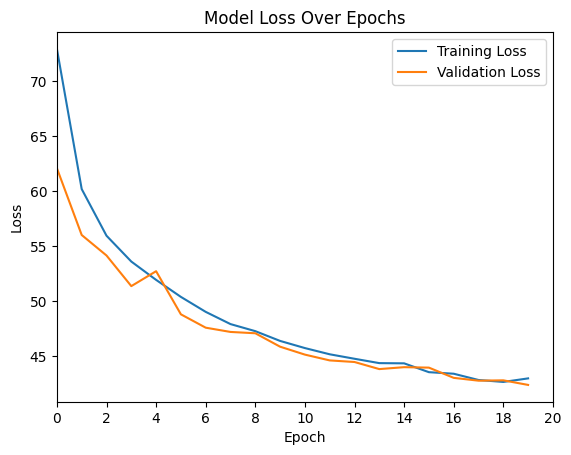

In [ ]:
# Plotting Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xlim([0, 20])
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # Set major tick locator to integer values
plt.show()

Both losses decrease across epochs, suggesting that the model is not overtrained.

In [ ]:
# Make prediction
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=-1).flatten()
true_labels = y_test.flatten()

# Filter out padding value (0) if used
mask = true_labels > 0
predictions = predictions[mask]
true_labels = true_labels[mask]

# Accuracy
print("Accuracy:", accuracy_score(true_labels, predictions))

# Classification Report
print(classification_report(true_labels, predictions, target_names=['.', '(', ')']))

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predictions)
print(conf_matrix)

245/245 [==============================] - 4s 9ms/step
Accuracy: 0.7884098909682321
              precision    recall  f1-score   support

           .       0.77      0.86      0.81    379012
           (       0.82      0.70      0.76    184330
           )       0.81      0.72      0.76    184330

    accuracy                           0.79    747672
   macro avg       0.80      0.76      0.78    747672
weighted avg       0.79      0.79      0.79    747672

[[326973  25247  26792]
 [ 50585 129693   4052]
 [ 48368   3156 132806]]


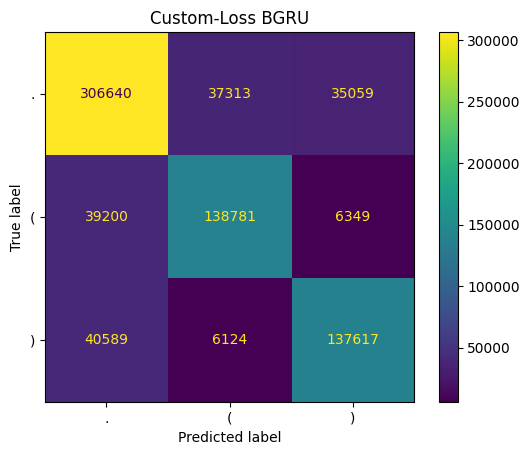

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['.','(',')'])
disp.plot()
plt.title("Custom-Loss BGRU")
plt.show()

With the current definition of the custom loss, the performance of the model does not improve when compared with bidirectional GRU. This suggests:
- The current penalty definition of probability sum, which is a broad metric, is not yet sensitive to unphysical representation of RNA. A more specific penalty loss, which accounts for individual base pairing positions may help.
- The penalty strength is not enough. Currently α is set to 0.1, and increasing this value may help.
- The prediction of cross-entropy loss BGRU is good enough that there is not a significant number of unphysical representation predictions of RNA.

## 5.4 Discussion

**Overview of Model Performance**

The development and evaluation of the Gated Recurrent Units (GRU) and Bidirectional GRU (BGRU) models aimed to tackle the classification of RNA nucleotides into three structural categories: unpaired (`.`), and paired (`(`, `)`). The GRU models were specifically designed to leverage the sequential nature of RNA data, capturing dependencies and context that are crucial for accurately predicting RNA secondary structures.

**Model Architectures and Training**

Both models utilized an embedding layer to transform nucleotide integer encodings into dense vectors, providing a nuanced representation that goes beyond basic integer encodings. This was followed by GRU layers (unidirectional or bidirectional) that processed these embeddings to capture temporal dependencies within the RNA sequences.

The training process demonstrated a steady decrease in both training and validation losses, indicating effective learning without signs of overfitting. This was particularly evident with the BGRU model, where the bidirectional approach helped improve overall accuracy and F1-scores across classes, supporting the hypothesis that capturing contextual information from both directions can lead to better predictive performance.

**Evaluation of Models**

The evaluation metrics used were precision, recall, accuracy, and F1-score, providing a comprehensive view of model performance. The BGRU model, with its bidirectional processing, achieved higher scores across these metrics compared to the unidirectional GRU model. This suggests that the bidirectional model is more adept at capturing the complex patterns in RNA sequences.

**Custom Loss Function to Address Unpaired Brackets**

A significant challenge in predicting RNA structures is ensuring that the predicted brackets are correctly paired, reflecting feasible physical structures. To address this, a custom loss function was introduced in the BGRU model, which included a penalty for unpaired brackets. However, the results from this approach did not show a marked improvement over the standard BGRU model.

This could indicate several things:

- Penalty Strength: The penalty coefficient may need adjustment. If too small, it might not exert enough influence to correct the pairing of brackets significantly.
- Loss Function Sensitivity: The current implementation of the penalty may not sufficiently capture the intricacies of RNA structure, particularly at the level of individual nucleotide pairings. A more targeted approach that directly evaluates the correctness of each predicted pairing might yield better results.

**Future Directions**

To further enhance the model's ability to predict accurate RNA structures, several approaches could be considered:

- Enhanced Penalty Mechanism: Adjusting the penalty terms or redesigning the loss function to more directly target the pairing accuracy could help. For instance, incorporating a dynamic programming method within the loss calculation to assess the feasibility of bracket closures might be more effective.
- Model Complexity and Regularization: Experimenting with more complex models or increased regularization might help manage the balance between fitting the training data and generalizing well to unseen data.
- Additional Contextual Features: Integrating more contextual features, such as the chemical properties of nucleotides or external binding factors, could potentially improve model predictions by providing additional relevant information.

# Part 6: Conclusion

1.  **Dataset and Exploratory Data Analysis**
- Utilized the comprehensive bpRNA dataset, with over 100,000 RNA sequences and structures.
- The raw data were extracted, transformed, and loaded (ETL) into workable Pandas DataFrames that contain useful information of RNA sequences and secondary structures.
- Length distribution of RNA and secondary structures, correlation between lengths and compositions, and composition distribution were investigated, revealing interesting trends such as the strong linear correlation between RNA length and the total number of secondary structures, or between the total number of stems and total number of ends.

2. **Regression Problem** - Prediction of Number of Substructures from RNA Sequence
- The RNN model showed better R2 scores for the seven substructures as compared to the FNN model.
- The RNN model performance was not good enough for validation loss in the training epochs. This suggests that the LSTM in the RNN could not accurately capture the sequence information.
- One hyposthesis is that the similiarity in RNA sequences in the training data results in poor model performance. The biased training data has over-representation of certain sequences as compared to others.

3. **Multiclass Classification Problem** - Prediction of Secondary Structure from RNA Sequence
- The models demonstrated a decrease in loss over training epochs, with no significant signs of overfitting, suggesting good model generalization on the validation set.
- The GRU models effectively classified RNA nucleotides into three structural classes (`.`, `(`, `)`), with the bidirectional model showing superior performance in terms of precision, recall, accuracy, and F1-score, demonstrating that leveraging sequence context from both directions enhances model performance.
- Incorporating a custom loss function aimed at penalizing unpaired brackets did not significantly outperform the standard loss models, suggesting the need for adjustments in penalty strength or loss definition.
4. **Limitations and Future Directions**
- The bpRNA data set has RNA sequences with significant similarity/overlap. This is potentially resulting in inadequate representation of different secondary strcutures.
- As future directions, cleaning and constraining the data set to remove sequences which are similar above a certrain threshold could be helpful. It would be a good exercise to conduct a parameter scan over the % similarity threshold, to understand how distinct the training data should be, in order to get the best model performances.
- Current models effectively predict basic structures but struggle with more complex arrangements like pseudoknots or intricate multi-loops, since we are limiting predictions to only round brackets.
- The constraint that each brackets must be paired is not yet applied strictly. Future strategies such as dynamic programming or better defined loss function need to be implemented.
- RNA sequence used for training and prediction is less than 500-nt due to limitation in data availability.
5. **Implications for Stakeholders**
- These findings are significant for researchers interested in RNA biology as they provide a robust tool for predicting RNA structure from sequence data, which is crucial for functional studies and therapeutic applications.
- The project also illustrates the effectiveness of neural network architectures in handling complex biological data.